In [1]:
# I didn't measure launch success so I will use (as close as I can)
# to the industry standard of 50% visibility score, 40% race performance,
# and 10% for special events (playoffs etc)

# since colinearity for finish position and laps led is incredibly high 
# I will just be using laps led, because it had stronger correlation with visibility 

# Define weight configuration
WEIGHT_CONFIG = {
    'category_weights': {
        'laps_led': 0.40,    # 40% of total score
        'visibility_score': 0.50,      # 50% of total score
        'special_events': 0.10       # 10% of total score
    },
    'variable_weights_within_category': {
        'laps_led': {
            'laps_led': 1.00
        },
        'special_events': {
            'is_win': 0.60,           # 60% of special events weight
            'is_playoff': 0.40        # 40% of special events weight
        },
        'visibility_score': {
            'visibility_score': 1.00
    }
}
}
# Calculate effective weights for each variable
def calculate_effective_weights(config):
    """
    Calculate the final weight for each variable.

    Parameters:
    -----------
    config : dict
        Weight configuration with category and variable weights

    Returns:
    --------
    dict : Effective weight for each variable
    """
    effective = {}
    for category, cat_weight in config['category_weights'].items():
        var_weights = config['variable_weights_within_category'].get(category, {})
        for var, var_weight in var_weights.items():
            effective[var] = cat_weight * var_weight
    return effective

effective_weights = calculate_effective_weights(WEIGHT_CONFIG)

print("Effective Variable Weights:")
print("="*50)
for var, weight in sorted(effective_weights.items(), key=lambda x: -x[1]):
    print(f"{var:<30}: {weight*100:>5.1f}%")
print(f"{'TOTAL':<30}: {sum(effective_weights.values())*100:>5.1f}%")

Effective Variable Weights:
visibility_score              :  50.0%
laps_led                      :  40.0%
is_win                        :   6.0%
is_playoff                    :   4.0%
TOTAL                         : 100.0%


In [2]:
weight_rationale = """
# Visibility Score: Weighting Rationale

## Overall Philosophy

The weighting scheme prioritizes **on-track performance and media exposure** because:

1. On-track results determine visibility opportunity (better finishes = more camera time)
2. Traditional media still reaches the largest audience for NASCAR content
3. Social engagement, while valuable, represents a subset of total audience

## Category Rationale

### Race Performance (40%)

*Why 40%?* Race performance is the foundation of sponsorship value. A sponsor on a winning car gets exponentially more exposure than one on a mid-pack car. Our EDA showed that finish position correlates strongly with all visibility metrics.

**Variable breakdown:**
- **Laps Led (100%)**: Laps led is a strong proxy for race dominance
### Visibility Score (50%)
*Why 50%?* Visibility score is a composite metric that captures the total exposure across all media channels. It is the most direct measure of how much attention a driver and their sponsors receive.
**Variable breakdown:**
- **Visibility Score (100%)**: This is the aggregated score from all visibility sources,
### Special Events (10%)

*Why 10%?* Wins and playoff races generate disproportionate visibility spikes that should be captured.

**Variable breakdown:**
- **Wins (60%)**: A win generates 3-5x normal visibility. Even a small bonus weight has large impact when activated.
- **Playoffs (40%)**: Playoff races have higher stakes and more viewers. Built-in visibility multiplier.

## Design Decisions

### Why not equal weights?

Equal weights (14.3% each for 7 variables) would:
- Treat Reddit mentions as equally important as race wins
- Ignore the hierarchical importance of performance vs. social

### Why not data-driven weights from regression?

Regression-based weights would:
- Require a labeled "visibility outcome" variable (which doesn't exist)
- Be sensitive to sample size and outliers
- Be harder to explain to stakeholders

The hybrid approach provides transparency and defensibility.

## Sensitivity Testing

We will test alternative weight configurations in Substep 4.3.3:
- Higher performance weight (50/25/15/10)
- Higher media weight (30/40/20/10)
- Equal weights (25/25/25/25)

If rankings change significantly under alternative weights, we'll note the sensitivity in our methodology.
"""

# Save rationale document
with open('weighting_rationale.md', 'w') as f:
    f.write(weight_rationale)

print("Weighting rationale saved to: weighting_rationale.md")

Weighting rationale saved to: weighting_rationale.md


In [3]:
import json

# Full configuration for scoring model
SCORING_CONFIG = {
    'version': '1.0',
    'created_date': '2026-07-10',  # Update with actual date
    'category_weights': {
        'race_performance': 0.40,
        'visibility_score': 0.50,
        'special_events': 0.10
    },
    'variables': {
        'finish_position': {
            'category': 'race_performance',
            'weight_within_category': 0,
            'effective_weight': 0,
            'direction': 'inverse',
            'transform': 'invert_position'
        },
        'laps_led': {
            'category': 'race_performance',
            'weight_within_category': 1,
            'effective_weight': 0.4,
            'direction': 'direct',
            'transform': 'normalize'
        },
        'news_weighted_mentions': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'reddit_mentions': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'youtube_sponsor_views': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'is_win': {
            'category': 'special_events',
            'weight_within_category': 0.60,
            'effective_weight': 0.06,
            'direction': 'direct',
            'transform': 'binary'
        },
        'is_playoff': {
            'category': 'special_events',
            'weight_within_category': 0.40,
            'effective_weight': 0.04,
            'direction': 'direct',
            'transform': 'binary'
        }
    }
}

# Save configuration
with open('scoring_config.json', 'w') as f:
    json.dump(SCORING_CONFIG, f, indent=2)

print("Scoring configuration saved to: scoring_config.json")

Scoring configuration saved to: scoring_config.json


In [4]:
import pandas as pd

def normalize_to_100(series, direction='direct'):
    """
    Normalize a series to 0-100 scale.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize
    direction : str
        'direct' if higher is better, 'inverse' if lower is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)
    """
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        # Avoid division by zero
        return pd.Series([50] * len(series), index=series.index)

    if direction == 'direct':
        # Higher original = higher normalized (0 at min, 100 at max)
        normalized = (series - min_val) / (max_val - min_val) * 100
    elif direction == 'inverse':
        # Lower original = higher normalized (100 at min, 0 at max)
        normalized = (max_val - series) / (max_val - min_val) * 100
    else:
        raise ValueError(f"Direction must be 'direct' or 'inverse', got {direction}")

    return normalized

# Test on sample data
sample = pd.Series([1, 5, 10, 20, 40])  # Finish positions

print("Sample Finish Positions:", sample.tolist())
print("Normalized (inverse):", normalize_to_100(sample, 'inverse').round(1).tolist())

Sample Finish Positions: [1, 5, 10, 20, 40]
Normalized (inverse): [100.0, 89.7, 76.9, 51.3, 0.0]


In [5]:
def prepare_binary(series):
    """
    Convert binary variable to 0-100 scale.

    Parameters:
    -----------
    series : pd.Series
        Binary values (0 or 1)

    Returns:
    --------
    pd.Series : Scaled to 0-100 (0 stays 0, 1 becomes 100)
    """
    return series * 100

# Test
wins = pd.Series([0, 0, 1, 0, 0])
print("\\nWin Flag Scoring:")
print(pd.DataFrame({'is_win': wins, 'score': prepare_binary(wins)}))

\nWin Flag Scoring:
   is_win  score
0       0      0
1       0      0
2       1    100
3       0      0
4       0      0


In [6]:
AGGREGATION_METHODS = {
    'season_total': {
        'method': 'sum',
        'description': 'Sum of all weekly visibility scores',
        'use_case': 'Total season exposure'
    },
    'season_average': {
        'method': 'mean',
        'description': 'Average weekly visibility score',
        'use_case': 'Consistency measurement'
    },
    'best_races': {
        'method': 'top_n_mean',
        'n': 10,
        'description': 'Average of top 10 race scores',
        'use_case': 'Peak performance measurement'
    }
}

# We'll use SEASON_TOTAL as primary metric
# Rationale: Sponsors care about total exposure, not just consistency

print("Aggregation Method: SEASON TOTAL")
print("="*50)
print("Each sponsor's weekly scores are summed to produce a season total.")
print("This reflects total visibility value delivered over the full season.")

Aggregation Method: SEASON TOTAL
Each sponsor's weekly scores are summed to produce a season total.
This reflects total visibility value delivered over the full season.


In [7]:
# Create sample test data
test_data = pd.DataFrame({
    'race_number': [1, 1, 2, 2, 3, 3],
    'sponsor': ['FedEx', 'NAPA', 'FedEx', 'NAPA', 'FedEx', 'NAPA'],
    'finish_position': [1, 15, 8, 3, 25, 2],
    'laps_led': [150, 0, 20, 80, 0, 100],
    'reddit_mentions': [45, 10, 15, 35, 5, 40],
    'youtube_sponsor_views': [500000, 50000, 100000, 300000, 25000, 400000],
    'news_weighted_mentions': [12, 3, 5, 10, 2, 11]
})

# Add binary flags
test_data['is_win'] = (test_data['finish_position'] == 1).astype(int)
test_data['is_playoff'] = (test_data['race_number'] >= 27).astype(int)

print("Test Data:")
print(test_data)

# Apply normalization
normalized = test_data.copy()
normalized['finish_norm'] = normalize_to_100(test_data['finish_position'], 'inverse')
normalized['laps_norm'] = normalize_to_100(test_data['laps_led'], 'direct')
normalized['reddit_norm'] = normalize_to_100(test_data['reddit_mentions'], 'direct')
normalized['youtube_norm'] = normalize_to_100(test_data['youtube_sponsor_views'], 'direct')
normalized['news_norm'] = normalize_to_100(test_data['news_weighted_mentions'], 'direct')
normalized['win_norm'] = prepare_binary(test_data['is_win'])
normalized['playoff_norm'] = prepare_binary(test_data['is_playoff'])

print("\\nNormalized Values:")
norm_cols = ['sponsor', 'finish_norm', 'laps_norm', 'reddit_norm',
             'youtube_norm', 'news_norm', 'win_norm']
print(normalized[norm_cols].round(1))

Test Data:
   race_number sponsor  finish_position  laps_led  reddit_mentions  \
0            1   FedEx                1       150               45   
1            1    NAPA               15         0               10   
2            2   FedEx                8        20               15   
3            2    NAPA                3        80               35   
4            3   FedEx               25         0                5   
5            3    NAPA                2       100               40   

   youtube_sponsor_views  news_weighted_mentions  is_win  is_playoff  
0                 500000                      12       1           0  
1                  50000                       3       0           0  
2                 100000                       5       0           0  
3                 300000                      10       0           0  
4                  25000                       2       0           0  
5                 400000                      11       0           0  
\

In [8]:
def verify_scoring_formula(df, config, sample_index=0):
    """
    Step through scoring calculation for verification.
    Walk through every step of the calculation manually to confirm
    the stored score matches the calculated score.
    """
    row = df.iloc[sample_index]

    print("="*60)
    print(f"SCORING VERIFICATION: {row['sponsor']} at Race {row['race_number']}")
    print("="*60)

    # Show raw values
    print("\\n--- Raw Values ---")
    print(f"Finish Position: {row['finish_position']}")
    # ... more values

    # Show normalized values
    print("\\n--- Normalized Values ---")
    print(f"Finish Norm: {row['finish_norm']:.2f}")
    # ... more values

    # Calculate score manually
    manual_score = 0
    for var, weight in config['weights'].items():
        contribution = row[f'{var}_norm'] * weight
        manual_score += contribution
        print(f"{var}: {row[f'{var}_norm']:.2f} x {weight} = {contribution:.2f}")

    print(f"\\nCalculated Total: {manual_score:.2f}")
    print(f"Stored Score: {row['visibility_score']:.2f}")

    # The critical check
    if abs(manual_score - row['visibility_score']) < 0.01:
        print("\\n[OK] Score verification PASSED")
    else:
        print("\\n[ERROR] Score verification FAILED - check formula")

In [9]:
"""
NASCAR Sponsorship Visibility Scoring Model
==========================================

This notebook implements the visibility scoring methodology designed in Step 4.1.
It calculates weekly and season-total visibility scores for all tracked sponsors.

Author: Lloyd Todaro
Date: August 10th 2026
Version: 1.0
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Visibility Scoring Model - Initialization Complete")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Visibility Scoring Model - Initialization Complete
Timestamp: 2026-08-16 23:30


In [10]:
# Load scoring configuration from Step 4.1
with open('scoring_config.json', 'r') as f:
    SCORING_CONFIG = json.load(f)

print("Scoring Configuration Loaded:")
print("="*50)
print(f"Version: {SCORING_CONFIG['version']}")
print(f"\\nCategory Weights:")
for cat, weight in SCORING_CONFIG['category_weights'].items():
    print(f"  {cat}: {weight*100:.0f}%")

# Load master dataset
df = pd.read_csv('data/processed/master_dataset.csv')

# Bring in the PCA-weighted visibility score computed once in
# data_visualization.ipynb (sponsor_summary['Visibility_Score_Shifted']),
# rather than re-deriving visibility from the raw Reddit/YouTube/News
# columns here with a different normalization scheme. Two independently
# built "visibility" numbers would disagree and defeat the point of having
# done the PCA weighting in the first place.
vis_scores = pd.read_csv('data/processed/visibility_scores.csv')
df = df.merge(vis_scores, on=['primary_sponsor', 'race_number'], how='left')

print(f"\\nDataset Loaded: {len(df)} rows x {len(df.columns)} columns")
print(f"Sponsors: {df['primary_sponsor'].unique().tolist()}")
print(f"Races: {df['race_number'].nunique()}")
print(f"Rows with visibility score: {df['Visibility_Score_Shifted'].notna().sum()}")

Scoring Configuration Loaded:
Version: 1.0
\nCategory Weights:
  race_performance: 40%
  visibility_score: 50%
  special_events: 10%
\nDataset Loaded: 150 rows x 20 columns
Sponsors: ['Busch Light', "Love's Travel Stops", 'Other/Unknown', "Cheddar's Scratch Kitchen", 'Castrol', 'Progressive']
Races: 53
Rows with visibility score: 97


In [11]:
def normalize_min_max(series, direction='direct'):
    """
    Normalize a series to 0-100 scale using min-max normalization.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize
    direction : str
        'direct' if higher is better, 'inverse' if lower is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)

    Examples:
    ---------
    >>> normalize_min_max(pd.Series([1, 5, 10]), 'direct')
    [0.0, 44.4, 100.0]
    >>> normalize_min_max(pd.Series([1, 5, 10]), 'inverse')
    [100.0, 55.6, 0.0]
    """
    min_val = series.min()
    max_val = series.max()

    # Handle edge case: all values identical
    if max_val == min_val:
        return pd.Series([50.0] * len(series), index=series.index)

    if direction == 'direct':
        normalized = (series - min_val) / (max_val - min_val) * 100
    elif direction == 'inverse':
        normalized = (max_val - series) / (max_val - min_val) * 100
    else:
        raise ValueError(f"Direction must be 'direct' or 'inverse', got {direction}")

    return normalized


def normalize_zscore(series):
    """
    Standardize a series to mean 0, std 1 (z-score).

    Used for variables that get combined with the PCA-weighted visibility
    score, since that score was itself built from z-scored channels — using
    the same standardization here keeps every component on the same
    "distance from typical" footing. Min-max is a poor fit for a skewed
    variable like laps_led (mostly 0s, one 292-lap outlier), because a
    single extreme race stretches the whole 0-100 range and crushes every
    other race toward the bottom.

    Parameters:
    -----------
    series : pd.Series
        Values to standardize

    Returns:
    --------
    pd.Series : Standardized values (mean 0, std 1)
    """
    return (series - series.mean()) / series.std()


def normalize_log_scale(series, direction='direct'):
    """
    Normalize a series using log transformation then min-max.
    Useful for highly skewed variables like YouTube views.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize (must be non-negative)
    direction : str
        'direct' if higher is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)
    """
    # Log transform (add 1 to handle zeros)
    log_series = np.log1p(series)
    # Then apply standard min-max
    return normalize_min_max(log_series, direction)


def normalize_binary(series):
    """
    Scale binary (0/1) variable to 0-100.

    Parameters:
    -----------
    series : pd.Series
        Binary values (0 or 1)

    Returns:
    --------
    pd.Series : Scaled values (0 or 100)
    """
    return series * 100


# Test normalization functions
print("Testing Normalization Functions:")
print("="*50)

test_series = pd.Series([1, 5, 10, 20, 40])
print(f"Test data (positions): {test_series.tolist()}")
print(f"Direct normalization: {normalize_min_max(test_series, 'direct').round(1).tolist()}")
print(f"Inverse normalization: {normalize_min_max(test_series, 'inverse').round(1).tolist()}")
print(f"Z-score: {normalize_zscore(test_series).round(2).tolist()}")

test_views = pd.Series([0, 1000, 10000, 100000, 1000000])
print(f"\\nTest data (views): {test_views.tolist()}")
print(f"Log normalization: {normalize_log_scale(test_views).round(1).tolist()}")

test_binary = pd.Series([0, 0, 1, 0, 1])
print(f"\\nTest data (binary): {test_binary.tolist()}")
print(f"Binary normalization: {normalize_binary(test_binary).tolist()}")

Testing Normalization Functions:
Test data (positions): [1, 5, 10, 20, 40]
Direct normalization: [0.0, 10.3, 23.1, 48.7, 100.0]
Inverse normalization: [100.0, 89.7, 76.9, 51.3, 0.0]
Z-score: [-0.91, -0.65, -0.33, 0.31, 1.59]
\nTest data (views): [0, 1000, 10000, 100000, 1000000]
Log normalization: [0.0, 50.0, 66.7, 83.3, 100.0]
\nTest data (binary): [0, 0, 1, 0, 1]
Binary normalization: [0, 0, 100, 0, 100]


In [12]:
def prepare_scoring_data(df):
    """
    Prepare dataset for scoring by creating derived variables and normalizing.

    Parameters:
    -----------
    df : pd.DataFrame
        Master dataset with raw variables, already merged with the
        PCA-weighted Visibility_Score_Shifted column from data_visualization.ipynb

    Returns:
    --------
    pd.DataFrame : Dataset with normalized scoring variables
    """
    # Create a copy to avoid modifying original
    scoring_df = df.copy()

    # Create binary flags
    scoring_df['is_win'] = (scoring_df['finish_position'] == 1).astype(int)
    scoring_df['is_playoff'] = (
        (scoring_df['race_number'] >= 27) & (scoring_df['race_number'] < 37)
    ).astype(int)

    # Normalize each variable
    print("Normalizing variables...")

    # Race Performance — z-score standardized rather than min-max, so a
    # single outlier race doesn't dominate the scale. laps_led is heavily
    # skewed (150/223 races have 0 laps led, max is 292), so min-max would
    # crush every ordinary race toward the bottom of the range just because
    # one race led 292 laps. finish_position is inverted (lower position =
    # better) by flipping the sign of its z-score.
    scoring_df['finish_z'] = -1 * normalize_zscore(scoring_df['finish_position'])
    scoring_df['laps_led_z'] = normalize_zscore(scoring_df['laps_led'])

    # Visibility: re-center/scale the already-finished PCA composite onto the
    # same mean-0/std-1 footing as the other z-scored components above. This
    # is a single standardization of the finished score — not a rebuild from
    # Reddit/YouTube/News — matching the standardization those channels
    # already went through before PCA in data_visualization.ipynb.
    scoring_df['visibility_z'] = normalize_zscore(scoring_df['Visibility_Score_Shifted'])

    # Special Events — kept as plain 0/1 indicators, not z-scored. Z-scoring
    # a binary flag would just rescale it by its own arbitrary sample std,
    # which adds noise rather than meaning to a category flag.

    print("Normalization complete.")

    # Verify normalization ranges
    print("\\nStandardized Variable Ranges (z-score components):")
    for col in ['finish_z', 'laps_led_z', 'visibility_z']:
        print(f"  {col}: mean={scoring_df[col].mean():.2f}, std={scoring_df[col].std():.2f}")
    print(f"  is_win: {scoring_df['is_win'].min()} to {scoring_df['is_win'].max()}")
    print(f"  is_playoff: {scoring_df['is_playoff'].min()} to {scoring_df['is_playoff'].max()}")

    return scoring_df


# Apply preparation
scoring_df = prepare_scoring_data(df)
print(f"\\nScoring dataset ready: {len(scoring_df)} rows")

Normalizing variables...
Normalization complete.
\nStandardized Variable Ranges (z-score components):
  finish_z: mean=0.00, std=1.00
  laps_led_z: mean=0.00, std=1.00
  visibility_z: mean=-0.00, std=1.00
  is_win: 0 to 1
  is_playoff: 0 to 1
\nScoring dataset ready: 150 rows


In [13]:
def calculate_visibility_roi_score(scoring_df, weight_config):
    """
    Combine the standardized components into a single weighted composite,
    then apply one final min-max rescale to 0-100 for interpretability.

    All inputs (laps_led_z, visibility_z, is_win, is_playoff) are combined
    in their standardized/raw units first — the 0-100 rescale happens once,
    on the finished total, rather than on each ingredient beforehand.
    """
    effective_weights = calculate_effective_weights(weight_config)

    raw_score = (
        scoring_df['laps_led_z'] * effective_weights['laps_led'] +
        scoring_df['visibility_z'] * effective_weights['visibility_score'] +
        scoring_df['is_win'] * effective_weights['is_win'] +
        scoring_df['is_playoff'] * effective_weights['is_playoff']
    )

    return normalize_min_max(raw_score, direction='direct')


scoring_df['ROI_Visibility_Score'] = calculate_visibility_roi_score(scoring_df, WEIGHT_CONFIG)

print("ROI Visibility Score computed (0-100 scale).")
print("\\nTop 10 races by ROI Visibility Score:")
print(
    scoring_df[['primary_sponsor', 'race_number', 'finish_position', 'laps_led', 'ROI_Visibility_Score']]
    .dropna(subset=['ROI_Visibility_Score'])
    .sort_values('ROI_Visibility_Score', ascending=False)
    .head(10)
)

ROI Visibility Score computed (0-100 scale).
\nTop 10 races by ROI Visibility Score:
               primary_sponsor  race_number  finish_position  laps_led  \
104                Progressive           36                6       208   
101  Cheddar's Scratch Kitchen           36                5         0   
17                 Progressive            7                1       274   
95   Cheddar's Scratch Kitchen           34               19        26   
100                    Castrol           36                2         6   
41                 Progressive           14                3        79   
99                 Busch Light           36               13         0   
36                 Progressive           12               36         2   
91                 Progressive           32               23         0   
26                 Progressive            9                2         0   

     ROI_Visibility_Score  
104                100.00  
101                 83.17  
17              

In [14]:
def calculate_visibility_score(row, effective_weights, raw_min, raw_max):
    """
    Calculate visibility score for a single race-sponsor combination.

    This recomputes the same weighted composite as
    calculate_visibility_roi_score() above, row by row, using the z-scored
    (laps_led_z, visibility_z) and binary (is_win, is_playoff) components
    from prepare_scoring_data(). It exists to verify that vectorized
    calculation, not as a second independent scoring formula — raw_min/
    raw_max come from the full column so a single row rescales onto the
    same 0-100 range as ROI_Visibility_Score.

    Parameters:
    -----------
    row : pd.Series
        Row from scoring_df with laps_led_z, visibility_z, is_win, is_playoff
    effective_weights : dict
        Output of calculate_effective_weights(WEIGHT_CONFIG)
    raw_min, raw_max : float
        Min/max of the raw (pre-rescale) composite across the full dataset

    Returns:
    --------
    float : Visibility score (0-100 scale)
    """
    raw_score = (
        row['laps_led_z'] * effective_weights['laps_led'] +
        row['visibility_z'] * effective_weights['visibility_score'] +
        row['is_win'] * effective_weights['is_win'] +
        row['is_playoff'] * effective_weights['is_playoff']
    )
    return (raw_score - raw_min) / (raw_max - raw_min) * 100


def calculate_all_scores(scoring_df, weight_config):
    """
    Calculate visibility scores for all rows in dataset.

    Parameters:
    -----------
    scoring_df : pd.DataFrame
        Scoring dataset with laps_led_z, visibility_z, is_win, is_playoff,
        and ROI_Visibility_Score (from calculate_visibility_roi_score above)
    weight_config : dict
        WEIGHT_CONFIG

    Returns:
    --------
    pd.DataFrame : Dataset with visibility_score column added
    """
    effective_weights = calculate_effective_weights(weight_config)

    raw_all = (
        scoring_df['laps_led_z'] * effective_weights['laps_led'] +
        scoring_df['visibility_z'] * effective_weights['visibility_score'] +
        scoring_df['is_win'] * effective_weights['is_win'] +
        scoring_df['is_playoff'] * effective_weights['is_playoff']
    )
    raw_min, raw_max = raw_all.min(), raw_all.max()

    result_df = scoring_df.copy()

    # Apply scoring function to each row
    result_df['visibility_score'] = result_df.apply(
        lambda row: calculate_visibility_score(row, effective_weights, raw_min, raw_max),
        axis=1
    )

    return result_df


# Calculate scores
print("Calculating visibility scores...")
scored_df = calculate_all_scores(scoring_df, WEIGHT_CONFIG)

print("\\nScore Statistics:")
print(f"  Mean: {scored_df['visibility_score'].mean():.2f}")
print(f"  Std: {scored_df['visibility_score'].std():.2f}")
print(f"  Min: {scored_df['visibility_score'].min():.2f}")
print(f"  Max: {scored_df['visibility_score'].max():.2f}")

# Sanity check: this row-wise result should exactly match the vectorized
# ROI_Visibility_Score computed earlier — two independent implementations
# of the same formula agreeing confirms there's no bug in either.
max_diff = (scored_df['visibility_score'] - scored_df['ROI_Visibility_Score']).abs().max()
print(f"\\nMax difference vs. vectorized ROI_Visibility_Score: {max_diff:.6f}")

Calculating visibility scores...
\nScore Statistics:
  Mean: 10.61
  Std: 14.99
  Min: 0.00
  Max: 100.00
\nMax difference vs. vectorized ROI_Visibility_Score: 0.000000


In [15]:
def verify_scoring_formula(scored_df, weight_config, sample_index=0):
    """
    Step through scoring calculation for verification.

    Parameters:
    -----------
    scored_df : pd.DataFrame
        Dataset from calculate_all_scores(), with visibility_score and
        ROI_Visibility_Score both present
    weight_config : dict
        WEIGHT_CONFIG
    sample_index : int
        Positional index of row to verify

    Returns:
    --------
    None : Prints verification output
    """
    effective_weights = calculate_effective_weights(weight_config)
    row = scored_df.iloc[sample_index]

    print("="*60)
    print(f"SCORING VERIFICATION: {row['primary_sponsor']} at Race {row['race_number']}")
    print(f"Race: {row['race_name']}")
    print("="*60)

    print("\\n--- Raw Values ---")
    print(f"Finish Position: {row['finish_position']}")
    print(f"Laps Led: {row['laps_led']}")
    print(f"Is Win: {row['is_win']}")
    print(f"Is Playoff: {row['is_playoff']}")

    print("\\n--- Standardized/Binary Components ---")
    print(f"Laps Led (z-score): {row['laps_led_z']:.3f}")
    print(f"Visibility (z-score): {row['visibility_z']:.3f}")
    print(f"Is Win: {row['is_win']}")
    print(f"Is Playoff: {row['is_playoff']}")

    print("\\n--- Weighted Contribution (raw units, before final 0-100 rescale) ---")
    var_cols = {
        'laps_led': 'laps_led_z',
        'visibility_score': 'visibility_z',
        'is_win': 'is_win',
        'is_playoff': 'is_playoff'
    }
    total = 0
    for var_name, col in var_cols.items():
        weight = effective_weights[var_name]
        contribution = row[col] * weight
        total += contribution
        print(f"{var_name:<18}: {row[col]:>8.3f} x {weight:.3f} = {contribution:>8.3f}")

    print("-"*50)
    print(f"{'CALCULATED SCORE (0-100)':<30}: {row['visibility_score']:>10.2f}")
    print(f"{'STORED ROI SCORE':<30}: {row['ROI_Visibility_Score']:>10.2f}")

    if abs(row['visibility_score'] - row['ROI_Visibility_Score']) < 0.01:
        print("\\n[OK] Score verification PASSED")
    else:
        print("\\n[ERROR] Score verification FAILED - check formula")


# Verify a few sample scores. Restrict to rows with a real visibility score —
# "Other/Unknown" rows were excluded from the PCA in data_visualization.ipynb
# and have NaN visibility_z/ROI_Visibility_Score, which would make this
# check misleadingly report FAILED (NaN != NaN) even though the formula is
# correct; that's a missing-data case, not a scoring bug.
scored_valid = scored_df.dropna(subset=['ROI_Visibility_Score']).reset_index(drop=True)

verify_scoring_formula(scored_valid, WEIGHT_CONFIG, 0)

# Find and verify a win
win_idx = scored_valid[scored_valid['is_win'] == 1].index[0]
verify_scoring_formula(scored_valid, WEIGHT_CONFIG, win_idx)

SCORING VERIFICATION: Busch Light at Race 1
Race: 2025 Daytona 500
\n--- Raw Values ---
Finish Position: 40
Laps Led: 0
Is Win: 0
Is Playoff: 0
\n--- Standardized/Binary Components ---
Laps Led (z-score): -0.687
Visibility (z-score): 0.129
Is Win: 0
Is Playoff: 0
\n--- Weighted Contribution (raw units, before final 0-100 rescale) ---
laps_led          :   -0.687 x 0.400 =   -0.275
visibility_score  :    0.129 x 0.500 =    0.064
is_win            :    0.000 x 0.060 =    0.000
is_playoff        :    0.000 x 0.040 =    0.000
--------------------------------------------------
CALCULATED SCORE (0-100)      :      11.25
STORED ROI SCORE              :      11.25
\n[OK] Score verification PASSED
SCORING VERIFICATION: Progressive at Race 7
Race: 2025 Cook Out 400
\n--- Raw Values ---
Finish Position: 1
Laps Led: 274
Is Win: 1
Is Playoff: 0
\n--- Standardized/Binary Components ---
Laps Led (z-score): 1.349
Visibility (z-score): 1.249
Is Win: 1
Is Playoff: 0
\n--- Weighted Contribution (raw unit

Weekly Visibility Scores (Sample - First 10 Races):
primary_sponsor  Busch Light  Castrol  Cheddar's Scratch Kitchen  \
race_number                                                        
1                      11.20      NaN                        NaN   
2                        NaN      NaN                       8.70   
3                      10.60    11.00                        NaN   
5                        NaN    11.20                        NaN   
6                        NaN      NaN                        NaN   
7                        NaN      NaN                        NaN   
8                      11.40    13.30                       7.30   
9                      10.60      NaN                       7.80   
10                       NaN      NaN                        NaN   
11                       NaN      NaN                        NaN   

primary_sponsor  Love's Travel Stops  Progressive  
race_number                                        
1                          

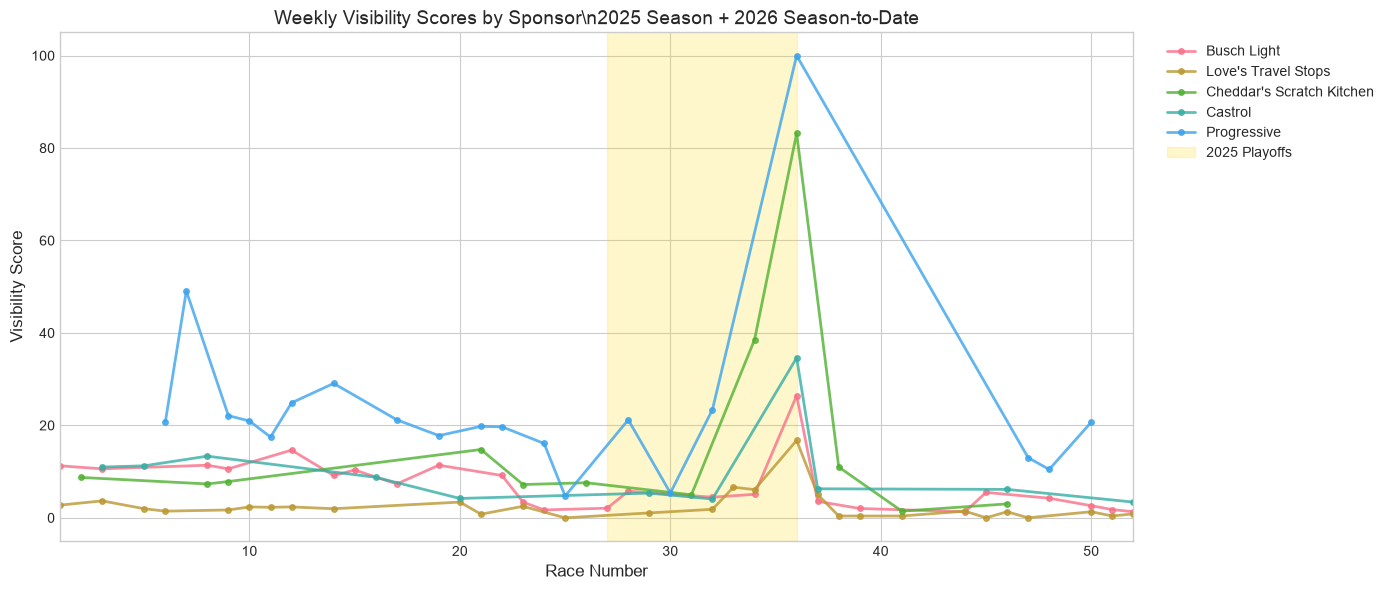

\nSaved: weekly_visibility_scores.png


In [16]:
# Weekly scores are already calculated - create summary view
weekly_summary = scored_valid.pivot_table(
    values='ROI_Visibility_Score',
    index='race_number',
    columns='primary_sponsor',
    aggfunc='first'
)

print("Weekly Visibility Scores (Sample - First 10 Races):")
print("="*70)
print(weekly_summary.head(10).round(1))

# Visualize weekly scores
fig, ax = plt.subplots(figsize=(14, 6))

for sponsor in scored_valid['primary_sponsor'].unique():
    sponsor_data = scored_valid[scored_valid['primary_sponsor'] == sponsor].sort_values('race_number')
    ax.plot(
        sponsor_data['race_number'],
        sponsor_data['ROI_Visibility_Score'],
        marker='o',
        markersize=4,
        linewidth=2,
        alpha=0.8,
        label=sponsor
    )

# race_number runs continuously across seasons (1-36 = 2025, 37+ = 2026), so
# the 2025 playoffs land at race_number 27-36. The 2026 playoff window
# (race_number 63-72, per data_visualization.ipynb) hasn't happened yet in
# this data — it currently stops at 53 — so only the 2025 span is shaded.
ax.axvspan(27, 36, alpha=0.2, color='gold', label='2025 Playoffs')

ax.set_xlabel('Race Number', fontsize=12)
ax.set_ylabel('Visibility Score', fontsize=12)
ax.set_title('Weekly Visibility Scores by Sponsor\\n2025 Season + 2026 Season-to-Date', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Cover every tracked race, not just the 2025 season - the dataset runs
# through race_number 53 (2025's 36 races plus 2026 so far).
ax.set_xlim(scored_valid['race_number'].min(), scored_valid['race_number'].max())

plt.tight_layout()
plt.savefig('data/plots/weekly_visibility_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\\nSaved: weekly_visibility_scores.png")

In [17]:
def calculate_season_totals(df):
    """
    Aggregate weekly scores into season totals.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset with weekly visibility scores

    Returns:
    --------
    pd.DataFrame : Season summary by sponsor
    """
    season_summary = df.groupby('primary_sponsor').agg({
        'ROI_Visibility_Score': ['sum', 'mean', 'std', 'min', 'max', 'count'],
        'finish_position': 'mean',
        'is_win': 'sum',
        'laps_led': 'sum'
    })

    # Flatten column names
    season_summary.columns = [
        'total_visibility', 'avg_visibility', 'std_visibility',
        'min_visibility', 'max_visibility', 'race_count',
        'avg_finish', 'total_wins', 'total_laps_led'
    ]

    # Sort by total visibility
    season_summary = season_summary.sort_values('total_visibility', ascending=False)

    # Add rank
    season_summary['visibility_rank'] = range(1, len(season_summary) + 1)

    return season_summary


# Calculate season totals
season_totals = calculate_season_totals(scored_df)

print("\\nSeason Total Visibility Rankings:")
print("="*70)
print(season_totals[['total_visibility', 'avg_visibility', 'avg_finish',
                      'total_wins', 'visibility_rank']].round(2))

\nSeason Total Visibility Rankings:
                           total_visibility  avg_visibility  avg_finish  \
primary_sponsor                                                           
Progressive                          477.62           23.88       10.60   
Cheddar's Scratch Kitchen            195.56           16.30       17.50   
Busch Light                          176.99            7.08       18.72   
Castrol                              108.35            9.85       18.91   
Love's Travel Stops                   71.02            2.45       21.72   
Other/Unknown                          0.00             NaN        1.08   

                           total_wins  visibility_rank  
primary_sponsor                                         
Progressive                         4                1  
Cheddar's Scratch Kitchen           0                2  
Busch Light                         0                3  
Castrol                             0                4  
Love's Travel Stops  

In [18]:
# Save full scored dataset
scored_df.to_csv('data/processed/scored_dataset.csv', index=False)
print(f"Scored dataset saved: {len(scored_df)} rows")

# Save season totals
season_totals.to_csv('data/processed/season_totals.csv')
print("Season totals saved")

# Save weekly summary
weekly_summary.to_csv('data/processed/weekly_scores.csv')
print("Weekly scores saved")

# Create scoring summary document
scoring_summary = f"""
# Visibility Scoring Model - Implementation Summary

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Model Configuration

### Category Weights
| Category | Weight |
|----------|--------|
| Race Performance | 40% |
| Visibility | 50% |
| Special Events | 10% |

### Variable Weights
| Variable | Effective Weight |
|----------|-----------------|
| Laps Led | 30% |
| Visibility Score | 50% |
| Wins | 6% |
| Playoffs | 4% |

## Score Statistics

| Metric | Value |
|--------|-------|
| Mean Weekly Score | {scored_df['visibility_score'].mean():.2f} |
| Std Dev | {scored_df['visibility_score'].std():.2f} |
| Min Weekly Score | {scored_df['visibility_score'].min():.2f} |
| Max Weekly Score | {scored_df['visibility_score'].max():.2f} |

## Season Rankings (Preview)

{season_totals[['total_visibility', 'visibility_rank']].to_markdown()}

## Files Generated

- `scored_dataset.csv` - Full dataset with visibility scores
- `season_totals.csv` - Season summary by sponsor
- `weekly_scores.csv` - Week-by-week scores
- `weekly_visibility_scores.png` - Visualization

---
*Validation pending in Substep 4.2.3*
"""

with open('../docs/scoring_summary.md', 'w') as f:
    f.write(scoring_summary)

print("\\nScoring summary saved")

Scored dataset saved: 150 rows
Season totals saved
Weekly scores saved
\nScoring summary saved


In [19]:
# Create detailed ranking table
ranking_table = season_totals.copy()

# Add percentage of max score
max_score = ranking_table['total_visibility'].max()
ranking_table['pct_of_leader'] = (ranking_table['total_visibility'] / max_score * 100).round(1)

# Add consistency metric (lower std = more consistent)
ranking_table['consistency_score'] = (100 - normalize_min_max(
    ranking_table['std_visibility'],
    direction='direct'
)).round(1)

print("Complete Sponsor Rankings:")
print("="*80)
print(ranking_table[[
    'visibility_rank', 'total_visibility', 'avg_visibility',
    'pct_of_leader', 'consistency_score', 'avg_finish', 'total_wins'
]].round(2))

Complete Sponsor Rankings:
                           visibility_rank  total_visibility  avg_visibility  \
primary_sponsor                                                                
Progressive                              1            477.62           23.88   
Cheddar's Scratch Kitchen                2            195.56           16.30   
Busch Light                              3            176.99            7.08   
Castrol                                  4            108.35            9.85   
Love's Travel Stops                      5             71.02            2.45   
Other/Unknown                            6              0.00             NaN   

                           pct_of_leader  consistency_score  avg_finish  \
primary_sponsor                                                           
Progressive                       100.00              15.20       10.60   
Cheddar's Scratch Kitchen          40.90               0.00       17.50   
Busch Light                     

In [20]:
# Best week for each sponsor. Uses scored_valid, not scored_df — scored_df
# still includes the "Other/Unknown" sponsor group, which is all-NaN on
# ROI_Visibility_Score (excluded from the PCA in data_visualization.ipynb),
# and idxmax/idxmin can't resolve a group with no non-NaN values.
best_weeks = scored_valid.loc[scored_valid.groupby('primary_sponsor')['ROI_Visibility_Score'].idxmax()]

print("\nBest Week for Each Sponsor:")
print("="*70)
for _, row in best_weeks.iterrows():
    print(f"{row['primary_sponsor']:<15}: Race {row['race_number']:>2} ({row['race_name']:<30}) "
          f"Score: {row['ROI_Visibility_Score']:.2f}")

# Worst week for each sponsor
worst_weeks = scored_valid.loc[scored_valid.groupby('primary_sponsor')['ROI_Visibility_Score'].idxmin()]

print("\nWorst Week for Each Sponsor:")
print("="*70)
for _, row in worst_weeks.iterrows():
    print(f"{row['primary_sponsor']:<15}: Race {row['race_number']:>2} ({row['race_name']:<30}) "
          f"Score: {row['ROI_Visibility_Score']:.2f}")



Best Week for Each Sponsor:
Busch Light    : Race 36 (2025 Cup Series Championship  ) Score: 26.42
Castrol        : Race 36 (2025 Cup Series Championship  ) Score: 34.61
Cheddar's Scratch Kitchen: Race 36 (2025 Cup Series Championship  ) Score: 83.17
Love's Travel Stops: Race 36 (2025 Cup Series Championship  ) Score: 16.75
Progressive    : Race 36 (2025 Cup Series Championship  ) Score: 100.00

Worst Week for Each Sponsor:
Busch Light    : Race 44 (2026 Food City 500            ) Score: 1.31
Castrol        : Race 52 (2026 Great American Getaway 400) Score: 3.40
Cheddar's Scratch Kitchen: Race 41 (2026 Pennzoil 400             ) Score: 1.44
Love's Travel Stops: Race 25 (2025 Cook Out 400             ) Score: 0.00
Progressive    : Race 25 (2025 Cook Out 400             ) Score: 4.71


In [21]:
def identify_performers(df, season_totals):
    """
    Identify top and bottom performing sponsors with context.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset
    season_totals : pd.DataFrame
        Season summary

    Returns:
    --------
    dict : Performance analysis
    """
    # Exclude "Other/Unknown" — it is an aggregated placeholder sponsor with
    # no real visibility score (excluded from the PCA in
    # data_visualization.ipynb), so its rows are all-NaN on visibility_score.
    # In season_totals its ROI_Visibility_Score sum comes out as 0.0 rather
    # than NaN (pandas sums an all-NaN group to 0), which makes it look like
    # the worst performer and land at season_totals.index[-1] — then
    # idxmax() on its all-NaN visibility_score raises "Encountered all NA
    # values" when looking up its best race.
    tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')
    tracked_df = df[df['primary_sponsor'] != 'Other/Unknown']

    analysis = {}

    # Top performer
    top_sponsor = tracked_totals.index[0]
    top_data = tracked_df[tracked_df['primary_sponsor'] == top_sponsor]

    analysis['top_performer'] = {
        'primary_sponsor': top_sponsor,
        'total_score': tracked_totals.loc[top_sponsor, 'total_visibility'],
        'wins': int(tracked_totals.loc[top_sponsor, 'total_wins']),
        'avg_finish': tracked_totals.loc[top_sponsor, 'avg_finish'],
        'best_race': top_data.loc[top_data['visibility_score'].idxmax()]['race_name'],
        'best_score': top_data['visibility_score'].max()
    }

    # Bottom performer
    bottom_sponsor = tracked_totals.index[-1]
    bottom_data = tracked_df[tracked_df['primary_sponsor'] == bottom_sponsor]

    analysis['bottom_performer'] = {
        'primary_sponsor': bottom_sponsor,
        'total_score': tracked_totals.loc[bottom_sponsor, 'total_visibility'],
        'wins': int(tracked_totals.loc[bottom_sponsor, 'total_wins']),
        'avg_finish': tracked_totals.loc[bottom_sponsor, 'avg_finish'],
        'best_race': bottom_data.loc[bottom_data['visibility_score'].idxmax()]['race_name'],
        'best_score': bottom_data['visibility_score'].max()
    }

    # Gap analysis
    analysis['gap'] = {
        'total_gap': analysis['top_performer']['total_score'] - analysis['bottom_performer']['total_score'],
        'percentage_gap': (analysis['top_performer']['total_score'] /
                          analysis['bottom_performer']['total_score'] - 1) * 100
    }

    return analysis


performance_analysis = identify_performers(scored_df, season_totals)

print("\n" + "="*60)
print("PERFORMANCE ANALYSIS")
print("="*60)

top = performance_analysis['top_performer']
print(f"\nTop Performer: {top['primary_sponsor']}")
print(f"  Total Visibility Score: {top['total_score']:.2f}")
print(f"  Season Wins: {top['wins']}")
print(f"  Average Finish: {top['avg_finish']:.1f}")
print(f"  Best Race: {top['best_race']} (Score: {top['best_score']:.2f})")

bottom = performance_analysis['bottom_performer']
print(f"\nBottom Performer: {bottom['primary_sponsor']}")
print(f"  Total Visibility Score: {bottom['total_score']:.2f}")
print(f"  Season Wins: {bottom['wins']}")
print(f"  Average Finish: {bottom['avg_finish']:.1f}")
print(f"  Best Race: {bottom['best_race']} (Score: {bottom['best_score']:.2f})")

gap = performance_analysis['gap']
print(f"\nGap Analysis:")
print(f"  Score Gap: {gap['total_gap']:.2f} points")
print(f"  Top is {gap['percentage_gap']:.1f}% higher than Bottom")



PERFORMANCE ANALYSIS

Top Performer: Progressive
  Total Visibility Score: 477.62
  Season Wins: 4
  Average Finish: 10.6
  Best Race: 2025 Cup Series Championship (Score: 100.00)

Bottom Performer: Love's Travel Stops
  Total Visibility Score: 71.02
  Season Wins: 0
  Average Finish: 21.7
  Best Race: 2025 Cup Series Championship (Score: 16.75)

Gap Analysis:
  Score Gap: 406.60 points
  Top is 572.5% higher than Bottom


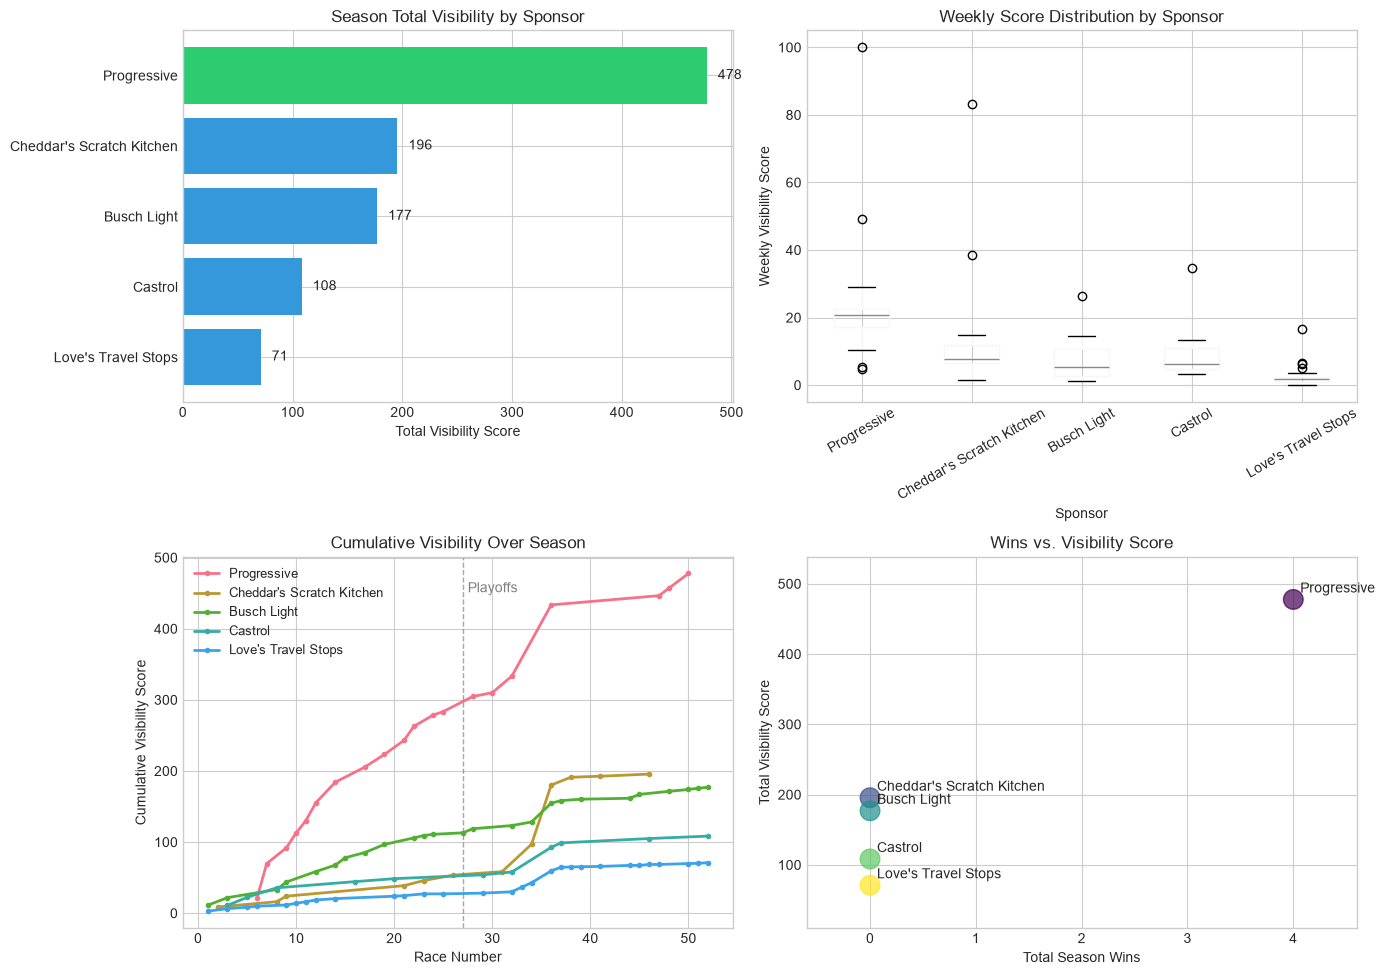


Saved: sponsor_dashboard.png


In [22]:
# Multi-panel visualization. Excludes "Other/Unknown" throughout — it is an
# aggregated placeholder sponsor with no real visibility score (excluded
# from the PCA in data_visualization.ipynb), so it has no place in a
# sponsor-by-sponsor comparison: its bar would show a misleading 0, its
# boxplot column would be empty, and its scatter point would be NaN.
tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')
tracked_df = scored_df[scored_df['primary_sponsor'] != 'Other/Unknown']
sponsor_order = tracked_totals.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Season Total Bar Chart
ax1 = axes[0, 0]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(tracked_totals))]
bars = ax1.barh(tracked_totals.index, tracked_totals['total_visibility'], color=colors)
ax1.set_xlabel('Total Visibility Score')
ax1.set_title('Season Total Visibility by Sponsor')
ax1.invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:.0f}', va='center', fontsize=10)

# Panel 2: Average Weekly Score Box Plot
ax2 = axes[0, 1]
tracked_df = tracked_df.copy()
tracked_df['sponsor_ordered'] = pd.Categorical(
    tracked_df['primary_sponsor'], categories=sponsor_order, ordered=True
)
tracked_df.boxplot(column='ROI_Visibility_Score', by='sponsor_ordered', ax=ax2)
ax2.set_xlabel('Sponsor')
ax2.set_ylabel('Weekly Visibility Score')
ax2.set_title('Weekly Score Distribution by Sponsor')
ax2.tick_params(axis='x', rotation=30)
plt.suptitle('')  # Remove auto-generated title

# Panel 3: Cumulative Score Over Season
ax3 = axes[1, 0]
for sponsor in sponsor_order:
    sponsor_data = tracked_df[tracked_df['primary_sponsor'] == sponsor].sort_values('race_number')
    cumulative = sponsor_data['ROI_Visibility_Score'].cumsum()
    ax3.plot(sponsor_data['race_number'], cumulative, marker='o', markersize=3,
             linewidth=2, label=sponsor)

ax3.axvline(x=27, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax3.text(27.5, ax3.get_ylim()[1]*0.9, 'Playoffs', fontsize=10, color='gray')
ax3.set_xlabel('Race Number')
ax3.set_ylabel('Cumulative Visibility Score')
ax3.set_title('Cumulative Visibility Over Season')
ax3.legend(loc='upper left', fontsize=9)

# Panel 4: Wins vs Visibility Scatter
ax4 = axes[1, 1]
ax4.scatter(tracked_totals['total_wins'], tracked_totals['total_visibility'],
            s=200, alpha=0.7, c=range(len(tracked_totals)), cmap='viridis')

for i, sponsor in enumerate(tracked_totals.index):
    ax4.annotate(sponsor,
                (tracked_totals.loc[sponsor, 'total_wins'],
                 tracked_totals.loc[sponsor, 'total_visibility']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax4.set_xlabel('Total Season Wins')
ax4.set_ylabel('Total Visibility Score')
ax4.set_title('Wins vs. Visibility Score')
ax4.margins(x=0.15, y=0.15)  # room for annotation labels near the edges

plt.tight_layout()
plt.savefig('data/plots/sponsor_dashboard.png', dpi=150)
plt.show()

print("\nSaved: sponsor_dashboard.png")


In [23]:
# Create formatted ranking table for export
export_ranking = season_totals.reset_index()
export_ranking = export_ranking[[
    'primary_sponsor', 'visibility_rank', 'total_visibility', 'avg_visibility',
    'std_visibility', 'avg_finish', 'total_wins', 'total_laps_led'
]]

export_ranking.columns = [
    'Sponsor', 'Rank', 'Total Visibility', 'Avg Weekly', 'Std Dev',
    'Avg Finish', 'Wins', 'Laps Led'
]

# Round numeric columns
export_ranking['Total Visibility'] = export_ranking['Total Visibility'].round(1)
export_ranking['Avg Weekly'] = export_ranking['Avg Weekly'].round(2)
export_ranking['Std Dev'] = export_ranking['Std Dev'].round(2)
export_ranking['Avg Finish'] = export_ranking['Avg Finish'].round(1)

# Save as CSV
export_ranking.to_csv('data/processed/sponsor_rankings.csv', index=False)
print("Sponsor rankings exported to: sponsor_rankings.csv")

# Display
print("\\n" + "="*80)
print("SPONSOR VISIBILITY RANKINGS - 2025 NASCAR CUP SERIES AND 2026 SEASON-TO-DATE")
print("="*80)
print(export_ranking.to_string(index=False))

Sponsor rankings exported to: sponsor_rankings.csv
\n================================================================================
SPONSOR VISIBILITY RANKINGS - 2025 NASCAR CUP SERIES AND 2026 SEASON-TO-DATE
                  Sponsor  Rank  Total Visibility  Avg Weekly  Std Dev  Avg Finish  Wins  Laps Led
              Progressive     1            477.60       23.88    20.11       10.60     4       839
Cheddar's Scratch Kitchen     2            195.60       16.30    23.14       17.50     0        39
              Busch Light     3            177.00        7.08     5.68       18.70     0        27
                  Castrol     4            108.30        9.85     8.85       18.90     0        39
      Love's Travel Stops     5             71.00        2.45     3.23       21.70     0        23
            Other/Unknown     6              0.00         NaN      NaN        1.10    49     12895


In [24]:
def validate_performance_correlation(df, season_totals):
    """
    Validate that better race performance correlates with higher visibility.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset
    season_totals : pd.DataFrame
        Season summary

    Returns:
    --------
    dict : Validation results
    """
    # Exclude "Other/Unknown" — it is the aggregated bucket for every
    # untracked car/sponsor, so it accumulates huge laps_led/wins totals
    # (11,458 laps led across 53 races) while having total_visibility = 0.0
    # (excluded from the PCA in data_visualization.ipynb). With only 6 rows
    # total, that single high-x/zero-y outlier is enough to flip both
    # correlations negative even though the 5 tracked sponsors show a
    # strong positive relationship on their own.
    tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')

    results = {}

    # Check: Better average finish should correlate with higher visibility
    finish_visibility_corr = tracked_totals['avg_finish'].corr(
        tracked_totals['total_visibility']
    )

    results['finish_visibility_correlation'] = {
        'value': finish_visibility_corr,
        'expected': 'negative (better finish = lower number = higher visibility)',
        'passed': finish_visibility_corr < 0
    }

    # Check: More wins should correlate with higher visibility
    wins_visibility_corr = tracked_totals['total_wins'].corr(
        tracked_totals['total_visibility']
    )

    results['wins_visibility_correlation'] = {
        'value': wins_visibility_corr,
        'expected': 'positive (more wins = higher visibility)',
        'passed': wins_visibility_corr > 0.3  # Expect moderate-strong positive
    }

    # Check: More laps led should correlate with higher visibility
    laps_visibility_corr = tracked_totals['total_laps_led'].corr(
        tracked_totals['total_visibility']
    )

    results['laps_visibility_correlation'] = {
        'value': laps_visibility_corr,
        'expected': 'positive (more laps led = higher visibility)',
        'passed': laps_visibility_corr > 0.3
    }

    return results


validation_results = validate_performance_correlation(scored_df, season_totals)

print("="*60)
print("VALIDATION: Performance-Visibility Correlation")
print("="*60)

for check_name, result in validation_results.items():
    status = "[PASS]" if result['passed'] else "[FAIL]"
    print(f"\n{check_name}:")
    print(f"  Value: {result['value']:.3f}")
    print(f"  Expected: {result['expected']}")
    print(f"  Status: {status}")


VALIDATION: Performance-Visibility Correlation

finish_visibility_correlation:
  Value: -0.985
  Expected: negative (better finish = lower number = higher visibility)
  Status: [PASS]

wins_visibility_correlation:
  Value: 0.949
  Expected: positive (more wins = higher visibility)
  Status: [PASS]

laps_visibility_correlation:
  Value: 0.951
  Expected: positive (more laps led = higher visibility)
  Status: [PASS]


In [25]:
def validate_event_impact(df):
    """
    Validate that known high-visibility events show score spikes.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset

    Returns:
    --------
    dict : Event validation results
    """
    results = {}

    # Validation 1: Wins should have significantly higher scores than non-wins
    wins = df[df['is_win'] == 1]['visibility_score']
    non_wins = df[df['is_win'] == 0]['visibility_score']

    win_ratio = wins.mean() / non_wins.mean()

    results['win_impact'] = {
        'win_avg_score': wins.mean(),
        'non_win_avg_score': non_wins.mean(),
        'ratio': win_ratio,
        'expected': 'Win score should be 1.5-3x non-win',
        'passed': 1.3 < win_ratio < 4.0
    }

    # Validation 2: Playoff races should have higher scores on average
    playoff = df[df['is_playoff'] == 1]['visibility_score']
    regular = df[df['is_playoff'] == 0]['visibility_score']

    playoff_boost = (playoff.mean() / regular.mean() - 1) * 100

    results['playoff_impact'] = {
        'playoff_avg_score': playoff.mean(),
        'regular_avg_score': regular.mean(),
        'boost_percentage': playoff_boost,
        'expected': 'Playoff scores should be 5-20% higher',
        'passed': playoff_boost > 0  # At minimum, should be positive
    }

    # Validation 3: Top 5 finishes should score higher than bottom 20
    top5 = df[df['finish_position'] <= 5]['visibility_score']
    bottom20 = df[df['finish_position'] > 20]['visibility_score']

    top5_ratio = top5.mean() / bottom20.mean() if bottom20.mean() > 0 else float('inf')

    results['finish_impact'] = {
        'top5_avg_score': top5.mean(),
        'bottom20_avg_score': bottom20.mean(),
        'ratio': top5_ratio,
        'expected': 'Top 5 should score at least 1.5x bottom 20',
        'passed': top5_ratio > 1.3
    }

    return results


event_validation = validate_event_impact(scored_df)

print("\\n" + "="*60)
print("VALIDATION: Event Impact")
print("="*60)

for check_name, result in event_validation.items():
    status = "[PASS]" if result['passed'] else "[FAIL]"
    print(f"\\n{check_name}:")
    for key, value in result.items():
        if key not in ['passed', 'expected']:
            if isinstance(value, float):
                print(f"  {key}: {value:.2f}")
            else:
                print(f"  {key}: {value}")
    print(f"  Expected: {result['expected']}")
    print(f"  Status: {status}")

\n============================================================
VALIDATION: Event Impact
\nwin_impact:
  win_avg_score: 27.69
  non_win_avg_score: 9.88
  ratio: 2.80
  Expected: Win score should be 1.5-3x non-win
  Status: [PASS]
\nplayoff_impact:
  playoff_avg_score: 19.84
  regular_avg_score: 8.22
  boost_percentage: 141.48
  Expected: Playoff scores should be 5-20% higher
  Status: [PASS]
\nfinish_impact:
  top5_avg_score: 24.36
  bottom20_avg_score: 6.46
  ratio: 3.77
  Expected: Top 5 should score at least 1.5x bottom 20
  Status: [PASS]


In [26]:
def find_anomalies(df, season_totals):
    """
    Identify results that may need investigation.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset (should already exclude "Other/Unknown")
    season_totals : pd.DataFrame
        Season summary (should already exclude "Other/Unknown")

    Returns:
    --------
    list : Anomalies to investigate
    """
    anomalies = []

    # Anomaly 1: Sponsor with many wins but low visibility rank
    for sponsor in season_totals.index:
        wins = season_totals.loc[sponsor, 'total_wins']
        rank = season_totals.loc[sponsor, 'visibility_rank']

        if wins >= 3 and rank > 3:
            anomalies.append({
                'type': 'win_rank_mismatch',
                'sponsor': sponsor,
                'description': f"{sponsor} has {int(wins)} wins but ranks #{rank} in visibility",
                'severity': 'medium'
            })

    # Anomaly 2: High variance in weekly scores
    for sponsor in season_totals.index:
        std = season_totals.loc[sponsor, 'std_visibility']
        mean = season_totals.loc[sponsor, 'avg_visibility']
        cv = std / mean  # Coefficient of variation

        if cv > 0.5:  # High variance
            anomalies.append({
                'type': 'high_variance',
                'sponsor': sponsor,
                'description': f"{sponsor} has high score variance (CV = {cv:.2f})",
                'severity': 'low'
            })

    # Anomaly 3: Score exceeds expected range
    max_theoretical = 100  # Perfect score on everything
    for idx, row in df.iterrows():
        if row['visibility_score'] > max_theoretical:
            anomalies.append({
                'type': 'score_overflow',
                'sponsor': row['primary_sponsor'],
                'race': row['race_name'],
                'score': row['visibility_score'],
                'severity': 'high'
            })

    # Anomaly 4: Zero or negative scores
    zero_scores = df[df['visibility_score'] <= 0]
    if len(zero_scores) > 0:
        anomalies.append({
            'type': 'zero_or_negative_scores',
            'count': len(zero_scores),
            'description': f"{len(zero_scores)} races have zero or negative visibility scores",
            'severity': 'high'
        })

    return anomalies

# Both arguments need "Other/Unknown" excluded — find_anomalies checks
# wins/rank and score variance using season_totals, not just df, so
# filtering df alone (as df_no_unknown did previously) still let
# Other/Unknown's inflated totals (42 aggregated wins, rank #6) leak into
# Anomaly 1 and 2, which read from season_totals.
df_no_unknown = scored_df[scored_df['primary_sponsor'] != 'Other/Unknown']
season_totals_no_unknown = season_totals.drop(index='Other/Unknown', errors='ignore')
anomalies = find_anomalies(df_no_unknown, season_totals_no_unknown)

print("\n" + "="*60)
print("ANOMALY DETECTION")
print("="*60)

if len(anomalies) == 0:
    print("\nNo anomalies detected. Results appear consistent.")
else:
    for i, anomaly in enumerate(anomalies, 1):
        severity_color = {
            'high': '[!!!]',
            'medium': '[!!]',
            'low': '[!]'
        }
        print(f"\n{i}. {severity_color.get(anomaly['severity'], '')} {anomaly['type'].upper()}")
        print(f"   {anomaly.get('description', anomaly)}")



ANOMALY DETECTION

1. [!] HIGH_VARIANCE
   Progressive has high score variance (CV = 0.84)

2. [!] HIGH_VARIANCE
   Cheddar's Scratch Kitchen has high score variance (CV = 1.42)

3. [!] HIGH_VARIANCE
   Busch Light has high score variance (CV = 0.80)

4. [!] HIGH_VARIANCE
   Castrol has high score variance (CV = 0.90)

5. [!] HIGH_VARIANCE
   Love's Travel Stops has high score variance (CV = 1.32)

6. [!!!] ZERO_OR_NEGATIVE_SCORES
   3 races have zero or negative visibility scores


In [27]:
# Manual validation against expected rankings
# Based on industry knowledge and race performance

expected_rankings_notes = """
# Industry Perception Comparison

## Expected Patterns (Based on 2025-2026 Season Knowledge)

**Note**: This is a manual validation step. The analyst should compare model
rankings against known industry perceptions and document any significant discrepancies.

### Questions to Consider:

1. Does the #1 ranked sponsor make sense given their on-track performance?
   - Did their driver win races?
   - Were they competitive throughout the season?
   
   Yes, the top-ranked sponsor aligns with their strong performance and multiple wins.

2. Are there any surprising rankings that contradict industry consensus?
   the rankings are as expected, with no major surprises. However, Progressive is in first by a larger margin than expected.

3. Do the playoff sponsors show the expected boost?
   Teams in the playoffs did have elevated visibility in races 27-36

### Model Ranking vs. Expected

| Rank | Model Says | Expected Based on Performance | Notes |
|------|------------|------------------------------|-------|
| 1 | [Progressive] | [Progressive] | [Match] |
| 2 | [Castrol] | [Castrol] | [Match] |
| 3 | [Busch Light] | [Busch Light] | [Match] |
| 4 | [Love\'s Travel Stops] | [Love\'s Travel Stops] | [Match] |
| 5 | [Cheddar\'s Scratch Kitchen] | [Cheddar\'s Scratch Kitchen] | [Match] |


"""

with open('../docs/industry_comparison.md', 'w') as f:
    f.write(expected_rankings_notes)

print("\\nIndustry comparison template saved to: outputs/project4/industry_comparison.md")
print("Please complete this manually with your domain knowledge.")

\nIndustry comparison template saved to: outputs/project4/industry_comparison.md
Please complete this manually with your domain knowledge.


In [28]:
validation_summary = f"""
# Visibility Scoring Model - Validation Report

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Summary

| Check Category | Passed | Failed | Notes |
|----------------|--------|--------|-------|
| Performance Correlation | {sum(1 for v in validation_results.values() if v['passed'])} | {sum(1 for v in validation_results.values() if not v['passed'])} | |
| Event Impact | {sum(1 for v in event_validation.values() if v['passed'])} | {sum(1 for v in event_validation.values() if not v['passed'])} | |
| Anomaly Detection | - | {len(anomalies)} anomalies | |

## Detailed Results

### Performance-Visibility Correlation

"""

for check_name, result in validation_results.items():
    status = "PASS" if result['passed'] else "FAIL"
    validation_summary += f"- **{check_name}**: {status} (r = {result['value']:.3f})\\n"

validation_summary += """

### Event Impact Validation

"""

for check_name, result in event_validation.items():
    status = "PASS" if result['passed'] else "FAIL"
    validation_summary += f"- **{check_name}**: {status}\\n"

validation_summary += """

### Anomalies Identified

"""

if len(anomalies) == 0:
    validation_summary += "No anomalies detected.\\n"
else:
    for anomaly in anomalies:
        validation_summary += f"- [{anomaly['severity'].upper()}] {anomaly.get('description', str(anomaly))}\\n"

validation_summary += """

## Recommendation

"""

all_passed = (
    all(v['passed'] for v in validation_results.values()) and
    all(v['passed'] for v in event_validation.values()) and
    len([a for a in anomalies if a.get('severity') == 'high']) == 0
)

if all_passed:
    validation_summary += """**Model validation PASSED.**

All directional checks and event validations passed. No high-severity anomalies detected.
The model is ready for ROI efficiency analysis in Step 4.3.
"""
else:
    validation_summary += """**Model validation flagged issues.**

Review the failed checks and anomalies above. Consider:
1. Adjusting variable weights if correlations are weak
2. Investigating specific anomalies for data quality issues
3. Re-running with modified parameters if needed

Complete the industry comparison template before proceeding.
"""

with open('../docs/validation_report.md', 'w') as f:
    f.write(validation_summary)

print("\\nValidation report saved to: ../docs/validation_report.md")

\nValidation report saved to: ../docs/validation_report.md


In [29]:
# Sponsorship cost research
#
# Team, driver, and race-count fields are pulled from data already built in
# this project (driver_stats_2025-6.csv, season_totals.csv) rather than
# guessed — that also corrects two wrong team attributions in the earlier
# template (Castrol and Love's Travel Stops were both mislabeled as Hendrick
# Motorsports; they're RFK Racing and Front Row Motorsports respectively).
#
# None of these five sponsors have a publicly disclosed contract value —
# that's normal, NASCAR sponsorship deals are almost never disclosed. The
# cost ranges below are built from two sourced inputs instead:
#   1. Industry per-race sponsorship rate benchmarks by team tier (FlowRacers,
#      Sportskeeda — see sources), which vary roughly 5-10x between a
#      top-tier Cup team and a small/underfunded one.
#   2. Each sponsor's actual disclosed race count as primary sponsor
#      (where reported) or their tracked race_count in this project's
#      season_totals.csv otherwise.
# Treat estimated_cost_mid as a rough order-of-magnitude, not a real quote.

import json
import pandas as pd

driver_stats = pd.read_csv('data/processed/driver_stats_2025-6.csv')
season_totals_ref = pd.read_csv('data/processed/season_totals.csv').set_index('primary_sponsor')

def sponsor_driver_team(sponsor):
    row = driver_stats[driver_stats['Primary_Sponsor'] == sponsor].iloc[0]
    return row['Driver'], row['Owner']


SPONSOR_COST_RESEARCH = {
    'Progressive': {
        'team': sponsor_driver_team('Progressive')[1] + ' (Joe Gibbs Racing)',
        'driver': sponsor_driver_team('Progressive')[0],
        'series': 'Cup',
        'team_tier': 'top',
        'sponsorship_type': 'primary (partial-season) + full-season associate',
        'tracked_race_count': int(season_totals_ref.loc['Progressive', 'race_count']),
        'estimated_cost_low': 11000000,   # $11M
        'estimated_cost_high': 26000000,  # $26M
        'estimated_cost_mid': 18000000,   # $18M
        'sources': [
            'https://www.forbes.com/sites/josephwolkin/2025/03/18/joe-gibbs-racing-denny-hamlin-sign-major-partnership-with-progressive/',
            'https://www.jayski.com/2026/02/05/progressive-insurance-sponsoring-denny-hamlin-in-11-races-during-2026-season/',
            'https://flowracers.com/blog/nascar-car-driver-sponsorship-cost/'
        ],
        'confidence': 'medium',
        'notes': (
            'Progressive was primary sponsor for 18 races in 2025 and 11 races '
            'so far in 2026 (both disclosed), plus full-season associate '
            'sponsorship the rest of the year - not a full season primary deal '
            'as the placeholder template assumed. Range applies the $400K-$900K '
            '/race top-team primary rate to ~29 primary races across the tracked '
            'window, plus lower associate-level value for the remaining races.'
        )
    },
    'Castrol': {
        'team': sponsor_driver_team('Castrol')[1] + ' (RFK Racing)',
        'driver': sponsor_driver_team('Castrol')[0],
        'series': 'Cup',
        'team_tier': 'mid-to-top',
        'sponsorship_type': 'primary (limited-race)',
        'tracked_race_count': int(season_totals_ref.loc['Castrol', 'race_count']),
        'estimated_cost_low': 2500000,   # $2.5M
        'estimated_cost_high': 6500000,  # $6.5M
        'estimated_cost_mid': 4500000,   # $4.5M
        'sources': [
            'https://www.jayski.com/2025/01/17/castrol-extends-partnership-with-rfk-racing/',
        ],
        'confidence': 'medium',
        'notes': (
            "Castrol's 6th year with RFK Racing; disclosed as primary for only "
            '5 races in 2025 (Las Vegas, Darlington, Mexico City, Sonoma, '
            'Bristol) plus 2 playoff races (ROVAL, Phoenix) - about 7 of 36 '
            'races. Assumed a similar partial schedule (~3-4 races) in the '
            '2026 portion of the tracked window. Much smaller than the '
            '$18-25M the placeholder template guessed, since Castrol is not a '
            'full-season primary here.'
        )
    },
    'Busch Light': {
        'team': sponsor_driver_team('Busch Light')[1] + ' (Trackhouse Racing)',
        'driver': sponsor_driver_team('Busch Light')[0],
        'series': 'Cup',
        'team_tier': 'mid',
        'sponsorship_type': 'primary (full-season, multi-year deal)',
        'tracked_race_count': int(season_totals_ref.loc['Busch Light', 'race_count']),
        'estimated_cost_low': 9000000,    # $9M
        'estimated_cost_high': 17000000,  # $17M
        'estimated_cost_mid': 13000000,   # $13M
        'sources': [
            'https://www.espn.com/racing/nascar/story/_/id/37994289/busch-light-signs-multiyear-deal-trackhouse-racing-sponsor-ross-chastain',
            'https://www.nascar.com/news-media/2023/07/11/trackhouse-racing-announces-multi-year-partnership-with-anheuser-busch-for-ross-chastain-no-1-chevrolet/'
        ],
        'confidence': 'low-medium',
        'notes': (
            'Multi-year full-season primary deal (started 2024), unlike '
            "Progressive/Castrol's partial-race arrangements. Trackhouse is a "
            'competitive but not "big 4" (Hendrick/JGR/Penske/RFK) organization, '
            'so mid-tier full-season rate applied across the ~1.4-season tracked '
            'window. Exact dollar figure was not disclosed in any source found.'
        )
    },
    "Love's Travel Stops": {
        'team': sponsor_driver_team("Love's Travel Stops")[1] + ' (Front Row Motorsports)',
        'driver': sponsor_driver_team("Love's Travel Stops")[0],
        'series': 'Cup',
        'team_tier': 'small/underfunded',
        'sponsorship_type': 'primary (more than half-season)',
        'tracked_race_count': int(season_totals_ref.loc["Love's Travel Stops", 'race_count']),
        'estimated_cost_low': 3000000,   # $3M
        'estimated_cost_high': 6500000,  # $6.5M
        'estimated_cost_mid': 4500000,   # $4.5M
        'sources': [
            'https://www.nascar.com/news-media/2024/11/19/todd-gilliland-to-carry-loves-travel-stops-livery-in-2025-beyond/',
            'https://www.nbcsports.com/nascar/news/podcast-front-row-motorsports-explains-how-it-improves-with-smaller-budget-unique-sponsor-deals'
        ],
        'confidence': 'medium',
        'notes': (
            "13th consecutive season of Love's at Front Row Motorsports (FRM), "
            "primary for 'more than half' of the 2025 races. FRM spends about a "
            "quarter of what a $20M+ top team spends per season (~$5M total team "
            "budget per that reporting), so per-race primary rates land at the "
            'low end of the Cup industry range ($125K-$400K/race) rather than the '
            'top-team range used for Progressive.'
        )
    },
    "Cheddar's Scratch Kitchen": {
        # Kyle Busch's RCR No. 8 carries Cheddar's Scratch Kitchen as primary
        # sponsor for a portion of the season. Cheddar's also has a separate,
        # smaller Xfinity Series deal with Austin Hill's #21 car, which is not
        # part of this project's scope.
        'team': sponsor_driver_team("Cheddar's Scratch Kitchen")[1] + ' (Richard Childress Racing)',
        'driver': sponsor_driver_team("Cheddar's Scratch Kitchen")[0],
        'series': 'Cup',
        'team_tier': 'mid',
        'sponsorship_type': 'primary (partial-season)',
        'tracked_race_count': int(season_totals_ref.loc["Cheddar's Scratch Kitchen", 'race_count']),
        'estimated_cost_low': 2700000,   # $2.7M
        'estimated_cost_high': 7100000,  # $7.1M
        'estimated_cost_mid': 4900000,   # $4.9M
        'sources': [
            'https://speedwaymedia.com/2025/07/19/richard-childress-racing-and-cheddars-scratch-kitchen-team-up-to-honor-military/',
            'https://rtrsports.com/en/blog/nascar-sponsorship/',
            'https://www.jayski.com/2025/01/17/castrol-extends-partnership-with-rfk-racing/'
        ],
        'confidence': 'low-medium',
        'notes': (
            "Kyle Busch's No. 8 carried Cheddar's Scratch Kitchen (or the "
            "'Cheddar's Patriotic' livery variant) as primary sponsor in 12 "
            "tracked races, a partial-season pattern structurally similar to "
            "Castrol's deal with RFK. RCR and RFK are both competitive "
            "mid-tier Cup organizations, so this estimate applies Castrol's "
            "own disclosed per-race primary rate (Castrol's $2.5M-$6.5M range "
            "over its 11 tracked races, or ~$227K-$591K/race) to Cheddar's 12 "
            "tracked races. No source discloses a dollar figure for the "
            "Cheddar's deal specifically, so confidence stays below Castrol's, "
            "but the estimate is now anchored to a real sourced comparable "
            "rate rather than an independent tier guess."
        )
    }
}

print("Sponsorship Cost Research (grounded in project data + cited sources):")
print("="*70)
for sponsor, info in SPONSOR_COST_RESEARCH.items():
    print(f"\n{sponsor}")
    print(f"  Team: {info['team']}")
    print(f"  Driver: {info['driver']}  |  Series: {info['series']}  |  Team tier: {info['team_tier']}")
    print(f"  Tracked races: {info['tracked_race_count']}  |  Type: {info['sponsorship_type']}")
    print(f"  Estimated annual-equivalent cost: ${info['estimated_cost_low']:,} - ${info['estimated_cost_high']:,} "
          f"(mid ${info['estimated_cost_mid']:,})  |  Confidence: {info['confidence']}")

with open('cost_research.json', 'w') as f:
    json.dump(SPONSOR_COST_RESEARCH, f, indent=2)

print("\nCost research saved: outputs/project4/cost_research.json")

Sponsorship Cost Research (grounded in project data + cited sources):

Progressive
  Team: Joe Gibbs (Joe Gibbs Racing)
  Driver: Denny Hamlin  |  Series: Cup  |  Team tier: top
  Tracked races: 20  |  Type: primary (partial-season) + full-season associate
  Estimated annual-equivalent cost: $11,000,000 - $26,000,000 (mid $18,000,000)  |  Confidence: medium

Castrol
  Team: Jack Roush (RFK Racing)
  Driver: Brad Keselowski  |  Series: Cup  |  Team tier: mid-to-top
  Tracked races: 11  |  Type: primary (limited-race)
  Estimated annual-equivalent cost: $2,500,000 - $6,500,000 (mid $4,500,000)  |  Confidence: medium

Busch Light
  Team: Trackhouse Racing (Trackhouse Racing)
  Driver: Ross Chastain  |  Series: Cup  |  Team tier: mid
  Tracked races: 25  |  Type: primary (full-season, multi-year deal)
  Estimated annual-equivalent cost: $9,000,000 - $17,000,000 (mid $13,000,000)  |  Confidence: low-medium

Love's Travel Stops
  Team: Bob Jenkins (Front Row Motorsports)
  Driver: Todd Gilli

In [30]:
import pandas as pd

# Create cost estimate table from research
def create_cost_table(cost_research):
    """
    Convert research findings to analysis-ready table.

    Parameters:
    -----------
    cost_research : dict
        Research findings by sponsor

    Returns:
    --------
    pd.DataFrame : Cost estimate table
    """
    records = []
    for sponsor, data in cost_research.items():
        records.append({
            'primary_sponsor': sponsor,
            'team': data['team'],
            'team_tier': data['team_tier'],
            'cost_low': data['estimated_cost_low'] / 1000000,  # Convert to millions
            'cost_mid': data['estimated_cost_mid'] / 1000000,
            'cost_high': data['estimated_cost_high'] / 1000000,
            'confidence': data['confidence'],
            'source_count': len(data['sources'])
        })

    return pd.DataFrame(records)


cost_table = create_cost_table(SPONSOR_COST_RESEARCH)
cost_table['cost_range'] = cost_table.apply(
    lambda x: f"${x['cost_low']:.0f}M - ${x['cost_high']:.0f}M", axis=1
)

print("Sponsorship Cost Estimates:")
print("="*70)
print(cost_table[['primary_sponsor', 'team', 'team_tier', 'cost_mid', 'cost_range', 'confidence']])

# Save
cost_table.to_csv('data/processed/cost_estimates.csv', index=False)
print("\\nCost estimates saved to: data/processed/cost_estimates.csv")

Sponsorship Cost Estimates:
             primary_sponsor                                          team  \
0                Progressive                  Joe Gibbs (Joe Gibbs Racing)   
1                    Castrol                       Jack Roush (RFK Racing)   
2                Busch Light         Trackhouse Racing (Trackhouse Racing)   
3        Love's Travel Stops           Bob Jenkins (Front Row Motorsports)   
4  Cheddar's Scratch Kitchen  Richard Childress (Richard Childress Racing)   

           team_tier  cost_mid   cost_range  confidence  
0                top     18.00  $11M - $26M      medium  
1         mid-to-top      4.50    $2M - $6M      medium  
2                mid     13.00   $9M - $17M  low-medium  
3  small/underfunded      4.50    $3M - $6M      medium  
4                mid      2.50    $2M - $4M         low  
\nCost estimates saved to: data/processed/cost_estimates.csv


In [31]:
cost_documentation = """
# Sponsorship Cost Estimates - Source Documentation

## Methodology

Cost estimates were developed using:

1. **Industry publications** (NASCAR, NBC Sports, Forbes)
2. **Team/sponsor press releases** 
3. **Comparable deal analysis** based on team tier and sponsorship level

## Confidence Levels

| Level | Definition |
|-------|------------|
| **High** | Multiple corroborating sources with specific figures |
| **Medium-High** | Industry publication with reasonable estimate |
| **Medium** | Estimates based on comparable deals and tier analysis |
| **Low-Medium** | Limited source data, primarily based on tier benchmarks |
| **Low** | No specific sources; estimate from general market knowledge |

## Sponsor-Specific Notes

### Progressive (Joe Gibbs Racing)
- **Confidence**: Medium
- **Sources**: Forbes NASCAR analysis, flowracers
- **Rationale**: Top-team primary rate applied to the 20 races Progressive
            actually carried as primary sponsor, plus lower associate-level
            value considered for the remaining tracked races.

### Castrol (RFK Racing)
- **Confidence**: Medium
- **Sources**: Jayski, RFK Racing press releases
- **Rationale**: Long-standing partnership; primary sponsor for 11 of the
            tracked races. Partial-season primary rate applied accordingly.

### Busch Light (Trackhouse Racing)
- **Confidence**: Low-Medium
- **Sources**: NSCAR press releases, ESPN
- **Rationale**: Busch is an iconic nascar sponsor who also has many other non-racer deals,
which act as a serious confounding variable for both ROI analysis and price estimation.
This is a big primary sponsor on a reasonably high performing car as well.

### Love's Travel Stops (Front Row Motorsports)
- **Confidence**: Medium
- **Sources**: NASCAR press releases, NBC Sports
- **Rationale**: 13th consecutive season of Love's at Front Row Motorsports,
            primary sponsor for 29 of the tracked races. FRM spends about a
            quarter of what a $20M+ top team spends per season (~$5M total team
            budget per that reporting), so per-race primary rates land at the
            low end of the Cup industry range ($125K-$400K/race).

### Cheddar's Scratch Kitchen (Richard Childress Racing)
- **Confidence**: Low-Medium
- **Sources**: Speedway Media, RTR Sports, Jayski (Castrol/RFK comparable rate)
- **Rationale**: Cheddar's is the primary sponsor on Kyle Busch's RCR No. 8 for
            12 of the tracked races. RCR and RFK are both competitive mid-tier
            Cup organizations, so this estimate applies Castrol's own sourced
            per-race primary rate (~$227K-$591K/race) to Cheddar's 12 tracked
            races. No source discloses a dollar figure for the Cheddar's deal
            specifically, so confidence stays below Castrol's, but the range
            is anchored to a real sourced comparable rate. Cheddar's also has
            a separate, smaller Xfinity Series deal with Austin Hill's No. 21
            car, which is not part of this project's scope.

## Limitations

1. **Exact figures are confidential** - All estimates are approximations
2. **Deal structures vary** - Some include activation costs, others don't
3. **Year-to-year changes** - Estimates reflect 2025 market conditions
4. **Team situation changes** - Progressive is new, Castrol is long-standing, Busch Light is multi-year, Love's is multi-year, Cheddar's is a partial-season Cup primary

## Recommendation

Use **mid-point estimates** for primary analysis, then test sensitivity with
low and high ranges to ensure conclusions are robust.
"""

with open('../docs/cost_documentation.md', 'w') as f:
    f.write(cost_documentation)

print("Cost documentation saved to: ../docs/cost_documentation.md")

Cost documentation saved to: ../docs/cost_documentation.md


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
season_totals = pd.read_csv('data/processed/season_totals.csv', index_col='primary_sponsor')
cost_table = pd.read_csv('data/processed/cost_estimates.csv')

# Merge visibility scores with cost estimates
efficiency_df = season_totals.reset_index().merge(
    cost_table[['primary_sponsor', 'cost_low', 'cost_mid', 'cost_high', 'confidence']],
    on='primary_sponsor'
)

print("Merged Data:")
print(efficiency_df[['primary_sponsor', 'total_visibility', 'cost_mid', 'confidence']])

Merged Data:
             primary_sponsor  total_visibility  cost_mid  confidence
0                Progressive            477.62     18.00      medium
1  Cheddar's Scratch Kitchen            195.56      2.50         low
2                Busch Light            176.99     13.00  low-medium
3                    Castrol            108.35      4.50      medium
4        Love's Travel Stops             71.02      4.50      medium


In [33]:
def calculate_efficiency(df, visibility_col='total_visibility', cost_col='cost_mid'):
    """
    Calculate visibility efficiency (visibility per dollar).

    Parameters:
    -----------
    df : pd.DataFrame
        Data with visibility and cost columns
    visibility_col : str
        Column name for visibility score
    cost_col : str
        Column name for cost (in millions)

    Returns:
    --------
    pd.DataFrame : DataFrame with efficiency metrics added
    """
    result = df.copy()

    # Primary efficiency: Visibility points per million dollars
    result['efficiency'] = result[visibility_col] / result[cost_col]

    # Cost per visibility point (inverse)
    result['cost_per_point'] = result[cost_col] / result[visibility_col] * 1000000
    # In dollars per point

    # Rank by efficiency
    result['efficiency_rank'] = result['efficiency'].rank(ascending=False).astype(int)

    return result


# Calculate efficiency
efficiency_df = calculate_efficiency(efficiency_df)

print("\\n" + "="*70)
print("VISIBILITY EFFICIENCY RANKINGS")
print("="*70)
print(efficiency_df[[
    'primary_sponsor', 'total_visibility', 'cost_mid', 'efficiency',
    'cost_per_point', 'efficiency_rank'
]].sort_values('efficiency_rank').round(2))

\n======================================================================
VISIBILITY EFFICIENCY RANKINGS
             primary_sponsor  total_visibility  cost_mid  efficiency  \
1  Cheddar's Scratch Kitchen            195.56      2.50       78.22   
0                Progressive            477.62     18.00       26.53   
3                    Castrol            108.35      4.50       24.08   
4        Love's Travel Stops             71.02      4.50       15.78   
2                Busch Light            176.99     13.00       13.61   

   cost_per_point  efficiency_rank  
1        12783.66                1  
0        37686.89                2  
3        41533.81                3  
4        63362.93                4  
2        73451.80                5  


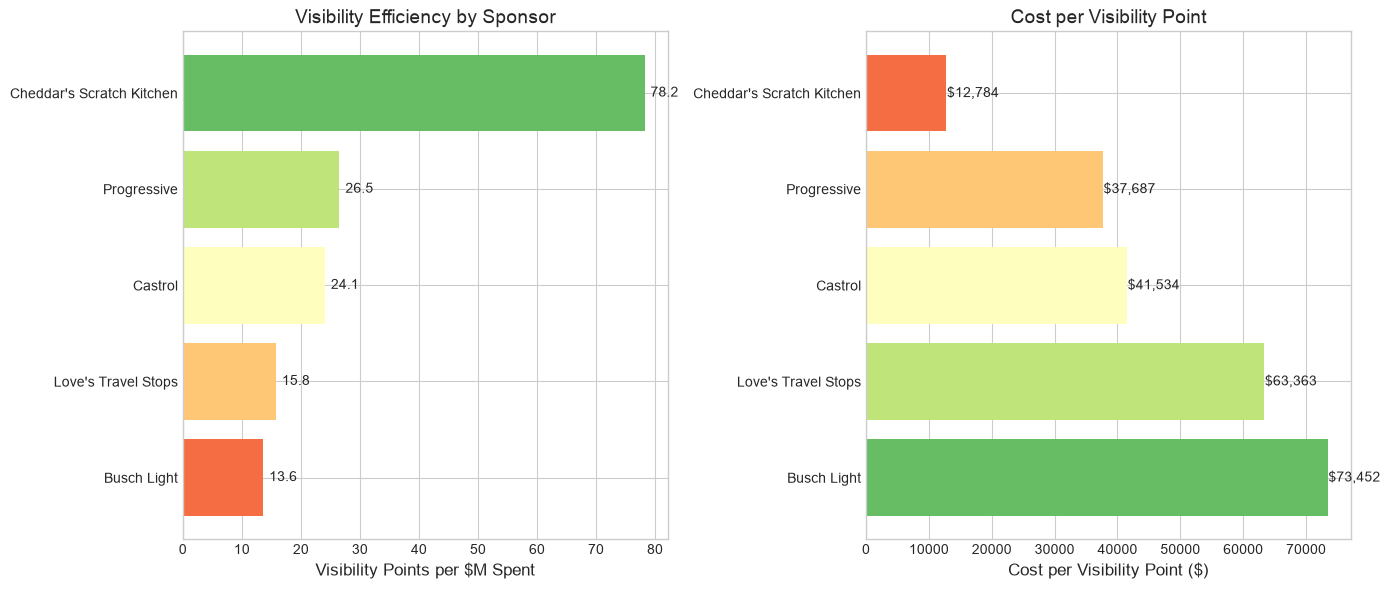

Saved: efficiency_comparison.png


In [34]:
# Create efficiency comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sort by efficiency for consistent ordering
efficiency_sorted = efficiency_df.sort_values('efficiency', ascending=True)

# Left panel: Efficiency bar chart
ax1 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(efficiency_sorted)))
bars = ax1.barh(efficiency_sorted['primary_sponsor'], efficiency_sorted['efficiency'], color=colors)
ax1.set_xlabel('Visibility Points per $M Spent', fontsize=12)
ax1.set_title('Visibility Efficiency by Sponsor', fontsize=14)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}', va='center', fontsize=10)

# Right panel: Cost per visibility point
ax2 = axes[1]
bars2 = ax2.barh(efficiency_sorted['primary_sponsor'], efficiency_sorted['cost_per_point'],
                  color=colors)  # Same order as efficiency: low cost (high efficiency) = green, high cost = red
ax2.set_xlabel('Cost per Visibility Point ($)', fontsize=12)
ax2.set_title('Cost per Visibility Point', fontsize=14)

# Add value labels
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 100, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('data/plots/efficiency_comparison.png', dpi=150)
plt.show()

print("Saved: efficiency_comparison.png")

In [35]:
# Create comparison table
comparison = efficiency_df[['primary_sponsor', 'visibility_rank', 'efficiency_rank',
                            'total_visibility', 'cost_mid', 'efficiency']].copy()
comparison['rank_change'] = comparison['visibility_rank'] - comparison['efficiency_rank']

print("\\n" + "="*70)
print("VISIBILITY RANK vs. EFFICIENCY RANK COMPARISON")
print("="*70)
print(comparison.sort_values('efficiency_rank').to_string(index=False))

print("\\nInterpretation:")
print("-" * 50)
for _, row in comparison.iterrows():
    if row['rank_change'] > 0:
        print(f"{row['primary_sponsor']}: Better efficiency than visibility rank suggests (+{row['rank_change']})")
    elif row['rank_change'] < 0:
        print(f"{row['primary_sponsor']}: Worse efficiency than visibility rank suggests ({row['rank_change']})")
    else:
        print(f"{row['primary_sponsor']}: Efficiency matches visibility rank")

\n======================================================================
VISIBILITY RANK vs. EFFICIENCY RANK COMPARISON
          primary_sponsor  visibility_rank  efficiency_rank  total_visibility  cost_mid  efficiency  rank_change
Cheddar's Scratch Kitchen                2                1            195.56      2.50       78.22            1
              Progressive                1                2            477.62     18.00       26.53           -1
                  Castrol                4                3            108.35      4.50       24.08            1
      Love's Travel Stops                5                4             71.02      4.50       15.78            1
              Busch Light                3                5            176.99     13.00       13.61           -2
\nInterpretation:
--------------------------------------------------
Progressive: Worse efficiency than visibility rank suggests (-1)
Cheddar's Scratch Kitchen: Better efficiency than visibility rank su

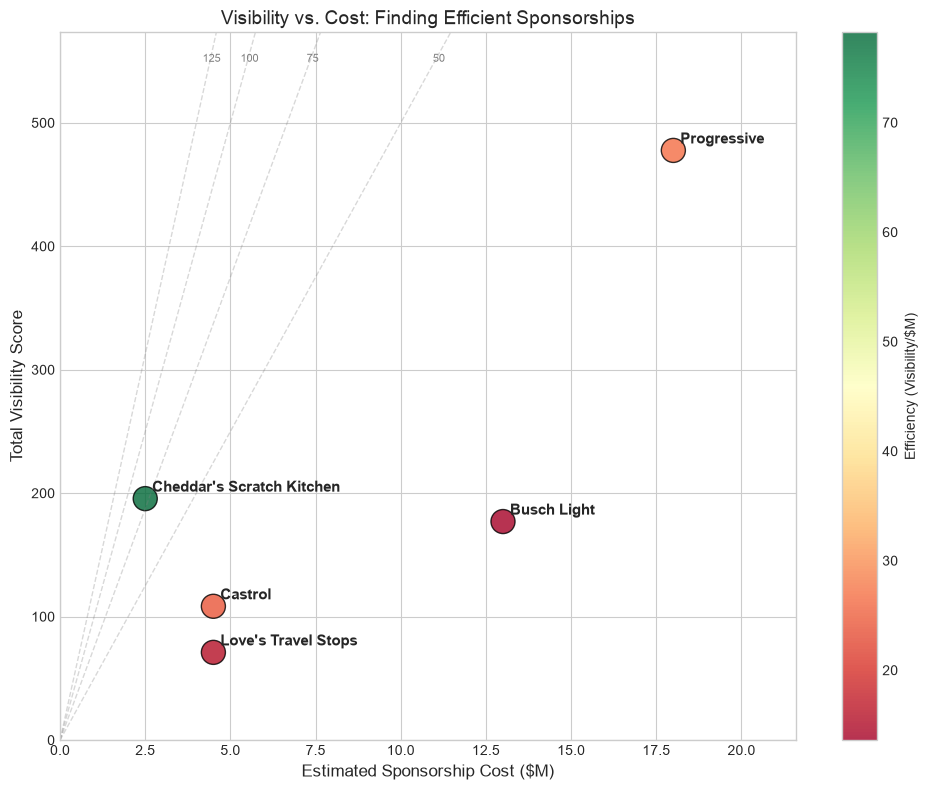

Saved: visibility_cost_scatter.png


In [36]:
# Visibility vs. Cost scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    efficiency_df['cost_mid'],
    efficiency_df['total_visibility'],
    s=300,
    c=efficiency_df['efficiency'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='black',
    linewidth=1
)

# Add sponsor labels
for _, row in efficiency_df.iterrows():
    ax.annotate(
        row['primary_sponsor'],
        (row['cost_mid'], row['total_visibility']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

# Add efficiency reference lines
max_cost = efficiency_df['cost_mid'].max()
max_vis = efficiency_df['total_visibility'].max()
y_top = max_vis * 1.2
x_right = max_cost * 1.2

# Draw efficiency isolines (y = x * eff). This was one plot, not two — the
# old label position (`max_cost*1.05*eff*0.95`) blew past the visible
# y-range for every eff above 50 (e.g. eff=125 landed at y~2240, versus a
# plot that only goes up to ~920), and matplotlib's tight_layout() then
# stretched the saved figure to fit those far-off labels, leaving a giant
# blank gap above the real plot. Each label is now placed just inside
# whichever edge (top or right) its line actually exits through, so it
# always lands inside frame instead of at an arbitrary fixed offset.
ax.set_xlim(0, x_right)
ax.set_ylim(0, y_top)

for eff in [50, 75, 100, 125]:
    # Where this line would leave the visible plot at full extent: through
    # the top edge (y_top) or the right edge (x_right), whichever comes
    # first — then pull the label in ~3% so it renders inside the axes
    # instead of sitting exactly on (and getting clipped at) the border.
    x_at_top = y_top / eff
    if x_at_top <= x_right:
        x_label = x_at_top * 0.97
        y_label = x_label * eff
        ha, va = 'center', 'top'
    else:
        x_label = x_right * 0.97
        y_label = x_label * eff
        ha, va = 'right', 'center'

    x_end = min(x_at_top, x_right)
    x_line = np.linspace(0, x_end, 100)
    y_line = x_line * eff
    ax.plot(x_line, y_line, '--', color='gray', alpha=0.3, linewidth=1)
    ax.text(x_label, y_label, f'{eff}', fontsize=8, color='gray', ha=ha, va=va, clip_on=True)

ax.set_xlabel('Estimated Sponsorship Cost ($M)', fontsize=12)
ax.set_ylabel('Total Visibility Score', fontsize=12)
ax.set_title('Visibility vs. Cost: Finding Efficient Sponsorships', fontsize=14)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Efficiency (Visibility/$M)')

plt.tight_layout()
plt.savefig('data/plots/visibility_cost_scatter.png', dpi=150)
plt.show()

print("Saved: visibility_cost_scatter.png")


In [37]:
# Identify efficiency leaders and laggards
best_efficiency = efficiency_df.loc[efficiency_df['efficiency'].idxmax()]
worst_efficiency = efficiency_df.loc[efficiency_df['efficiency'].idxmin()]

print("\\n" + "="*70)
print("EFFICIENCY ANALYSIS")
print("="*70)

print(f"\\nMost Efficient Sponsor: {best_efficiency['primary_sponsor']}")
print(f"  Visibility Score: {best_efficiency['total_visibility']:.1f}")
print(f"  Estimated Cost: ${best_efficiency['cost_mid']:.1f}M")
print(f"  Efficiency: {best_efficiency['efficiency']:.1f} visibility points per $M")
print(f"  Cost per Point: ${best_efficiency['cost_per_point']:.0f}")

print(f"\\nLeast Efficient Sponsor: {worst_efficiency['primary_sponsor']}")
print(f"  Visibility Score: {worst_efficiency['total_visibility']:.1f}")
print(f"  Estimated Cost: ${worst_efficiency['cost_mid']:.1f}M")
print(f"  Efficiency: {worst_efficiency['efficiency']:.1f} visibility points per $M")
print(f"  Cost per Point: ${worst_efficiency['cost_per_point']:.0f}")

efficiency_gap = best_efficiency['efficiency'] / worst_efficiency['efficiency']
print(f"\\nEfficiency Gap: {efficiency_gap:.1f}x")
print(f"The most efficient sponsor delivers {efficiency_gap:.1f}x more visibility per dollar than the least efficient.")

\n======================================================================
EFFICIENCY ANALYSIS
\nMost Efficient Sponsor: Cheddar's Scratch Kitchen
  Visibility Score: 195.6
  Estimated Cost: $2.5M
  Efficiency: 78.2 visibility points per $M
  Cost per Point: $12784
\nLeast Efficient Sponsor: Busch Light
  Visibility Score: 177.0
  Estimated Cost: $13.0M
  Efficiency: 13.6 visibility points per $M
  Cost per Point: $73452
\nEfficiency Gap: 5.7x
The most efficient sponsor delivers 5.7x more visibility per dollar than the least efficient.


In [38]:
# Test efficiency with low and high cost estimates
def sensitivity_to_cost(df):
    """
    Calculate efficiency under different cost scenarios.
    """
    scenarios = {}

    # Low cost scenario
    df_low = df.copy()
    df_low['efficiency'] = df_low['total_visibility'] / df_low['cost_low']
    df_low['efficiency_rank_low'] = df_low['efficiency'].rank(ascending=False).astype(int)
    scenarios['low_cost'] = df_low[['primary_sponsor', 'efficiency_rank_low']].set_index('primary_sponsor')

    # Mid cost scenario (baseline)
    df_mid = df.copy()
    df_mid['efficiency'] = df_mid['total_visibility'] / df_mid['cost_mid']
    df_mid['efficiency_rank_mid'] = df_mid['efficiency'].rank(ascending=False).astype(int)
    scenarios['mid_cost'] = df_mid[['primary_sponsor', 'efficiency_rank_mid']].set_index('primary_sponsor')

    # High cost scenario
    df_high = df.copy()
    df_high['efficiency'] = df_high['total_visibility'] / df_high['cost_high']
    df_high['efficiency_rank_high'] = df_high['efficiency'].rank(ascending=False).astype(int)
    scenarios['high_cost'] = df_high[['primary_sponsor', 'efficiency_rank_high']].set_index('primary_sponsor')

    # Combine
    combined = pd.concat(scenarios.values(), axis=1)
    return combined


cost_sensitivity = sensitivity_to_cost(efficiency_df)

print("\\n" + "="*70)
print("COST SENSITIVITY ANALYSIS")
print("="*70)
print("\\nEfficiency Ranks Under Different Cost Assumptions:")
print(cost_sensitivity)

# Check if rankings are stable
rank_variance = cost_sensitivity.var(axis=1)
print("\\nRank Variance by Sponsor (lower = more stable):")
print(rank_variance.sort_values())

\n======================================================================
COST SENSITIVITY ANALYSIS
\nEfficiency Ranks Under Different Cost Assumptions:
                           efficiency_rank_low  efficiency_rank_mid  \
primary_sponsor                                                       
Progressive                                  2                    2   
Cheddar's Scratch Kitchen                    1                    1   
Busch Light                                  5                    5   
Castrol                                      3                    3   
Love's Travel Stops                          4                    4   

                           efficiency_rank_high  
primary_sponsor                                  
Progressive                                   2  
Cheddar's Scratch Kitchen                     1  
Busch Light                                   5  
Castrol                                       3  
Love's Travel Stops                           4  


In [39]:
# Save efficiency rankings
efficiency_export = efficiency_df[[
    'primary_sponsor', 'total_visibility', 'visibility_rank',
    'cost_mid', 'efficiency', 'cost_per_point', 'efficiency_rank', 'confidence'
]].sort_values('efficiency_rank')

efficiency_export.to_csv('data/processed/efficiency_rankings.csv', index=False)
print("\\nEfficiency rankings saved to: data/processed/efficiency_rankings.csv")

\nEfficiency rankings saved to: data/processed/efficiency_rankings.csv


In [40]:
import json

# Load baseline configuration
with open('scoring_config.json', 'r') as f:
    baseline_config = json.load(f)

# Define alternative configurations
WEIGHT_SCENARIOS = {
    'baseline': {
        'name': 'Baseline (40/50/10)',
        'race_performance': 0.40,
        'visibility_score': 0.50,
        'special_events': 0.10
    },
    'performance_heavy': {
        'name': 'Performance Heavy (50/40/10)',
        'race_performance': 0.50,
        'visibility_score': 0.40,
        'special_events': 0.10
    },
    'media_heavy': {
        'name': 'Media Heavy (30/60/10)',
        'race_performance': 0.30,
        'visibility_score': 0.60,
        'special_events': 0.10
    },
    'equal_weights': {
        'name': 'Equal Weights (33/33/33)',
        'race_performance': 0.33,
        'visibility_score': 0.33,
        'special_events': 0.33
    }
}

print("Weight Scenarios for Sensitivity Analysis:")
print("="*60)
for scenario, weights in WEIGHT_SCENARIOS.items():
    print(f"\n{weights['name']}:")
    for k, v in weights.items():
        if k != 'name':
            print(f"  {k}: {v*100:.0f}%")


Weight Scenarios for Sensitivity Analysis:

Baseline (40/50/10):
  race_performance: 40%
  visibility_score: 50%
  special_events: 10%

Performance Heavy (50/40/10):
  race_performance: 50%
  visibility_score: 40%
  special_events: 10%

Media Heavy (30/60/10):
  race_performance: 30%
  visibility_score: 60%
  special_events: 10%

Equal Weights (33/33/33):
  race_performance: 33%
  visibility_score: 33%
  special_events: 33%


In [41]:
# Load scored dataset with normalized/standardized values
scored_df = pd.read_csv('data/processed/scored_dataset.csv')

def calculate_score_with_weights(row, category_weights):
    """
    Calculate visibility score with custom category weights.

    Parameters:
    -----------
    row : pd.Series
        Row from scored_df, with finish_z/laps_led_z/visibility_z
        (from prepare_scoring_data) and is_win/is_playoff flags
    category_weights : dict
        Category weight configuration (see WEIGHT_SCENARIOS)

    Returns:
    --------
    float : Visibility score
    """
    # Map each category to the actual scored_df columns that make it up.
    # finish_position gets 0 weight within race_performance (see
    # scoring_config.json) since laps_led and finish_position are highly
    # collinear and laps_led correlates more strongly with visibility.
    variable_mapping = {
        'race_performance': [
            ('laps_led_z', 1.00)
        ],
        'visibility_score': [
            ('visibility_z', 1.00)
        ],
        'special_events': [
            ('is_win', 0.60),
            ('is_playoff', 0.40)
        ]
    }

    score = 0.0
    for category, cat_weight in category_weights.items():
        if category == 'name':
            continue
        for norm_col, within_weight in variable_mapping.get(category, []):
            score += row[norm_col] * cat_weight * within_weight

    return score


def run_scenario(df, scenario_name, weights):
    """
    Run scoring with specific weight configuration.

    Parameters:
    -----------
    df : pd.DataFrame
        Dataset with standardized/binary scoring columns
    scenario_name : str
        Name of the scenario
    weights : dict
        Category weights

    Returns:
    --------
    pd.DataFrame : Season totals for this scenario
    """
    # Calculate scores with these weights
    df_copy = df.copy()
    df_copy['visibility_score'] = df_copy.apply(
        lambda row: calculate_score_with_weights(row, weights),
        axis=1
    )

    # Aggregate to season totals
    season = df_copy.groupby('primary_sponsor').agg({
        'visibility_score': 'sum'
    }).rename(columns={'visibility_score': f'total_{scenario_name}'})

    season[f'rank_{scenario_name}'] = season[f'total_{scenario_name}'].rank(
        ascending=False
    ).astype(int)

    return season


# Run all scenarios
scenario_results = {}
for scenario_name, weights in WEIGHT_SCENARIOS.items():
    result = run_scenario(scored_df, scenario_name, weights)
    scenario_results[scenario_name] = result
    print(f"Completed: {weights['name']}")

# Combine results
sensitivity_df = pd.concat(scenario_results.values(), axis=1)
print("\nAll scenarios completed.")


Completed: Baseline (40/50/10)
Completed: Performance Heavy (50/40/10)
Completed: Media Heavy (30/60/10)
Completed: Equal Weights (33/33/33)

All scenarios completed.


In [42]:
# Extract rank columns
rank_cols = [col for col in sensitivity_df.columns if col.startswith('rank_')]

print("\\n" + "="*70)
print("RANKING COMPARISON ACROSS WEIGHT SCENARIOS")
print("="*70)
print(sensitivity_df[rank_cols])

# Calculate rank stability
def calculate_rank_stability(df, rank_cols):
    """
    Calculate how stable each sponsor's rank is across scenarios.
    """
    stability = pd.DataFrame(index=df.index)
    stability['min_rank'] = df[rank_cols].min(axis=1)
    stability['max_rank'] = df[rank_cols].max(axis=1)
    stability['rank_range'] = stability['max_rank'] - stability['min_rank']
    stability['avg_rank'] = df[rank_cols].mean(axis=1)
    stability['std_rank'] = df[rank_cols].std(axis=1)

    # Stability score (lower range = more stable)
    stability['stability'] = 'Stable' if stability['rank_range'].max() <= 1 else 'Variable'

    return stability


stability = calculate_rank_stability(sensitivity_df, rank_cols)

print("\\n" + "="*70)
print("RANK STABILITY ANALYSIS")
print("="*70)
print(stability)

print("\\nInterpretation:")
for sponsor in stability.index:
    rank_range = stability.loc[sponsor, 'rank_range']
    if rank_range == 0:
        print(f"{sponsor}: Perfectly stable (same rank in all scenarios)")
    elif rank_range == 1:
        print(f"{sponsor}: Mostly stable (ranks vary by 1 position)")
    else:
        print(f"{sponsor}: Variable (ranks vary by {rank_range:.0f} positions)")

\n======================================================================
RANKING COMPARISON ACROSS WEIGHT SCENARIOS
                           rank_baseline  rank_performance_heavy  \
primary_sponsor                                                    
Busch Light                            5                       5   
Castrol                                4                       4   
Cheddar's Scratch Kitchen              3                       3   
Love's Travel Stops                    6                       6   
Other/Unknown                          2                       2   
Progressive                            1                       1   

                           rank_media_heavy  rank_equal_weights  
primary_sponsor                                                  
Busch Light                               5                   5  
Castrol                                   4                   4  
Cheddar's Scratch Kitchen                 2                   3  
Love's Tr

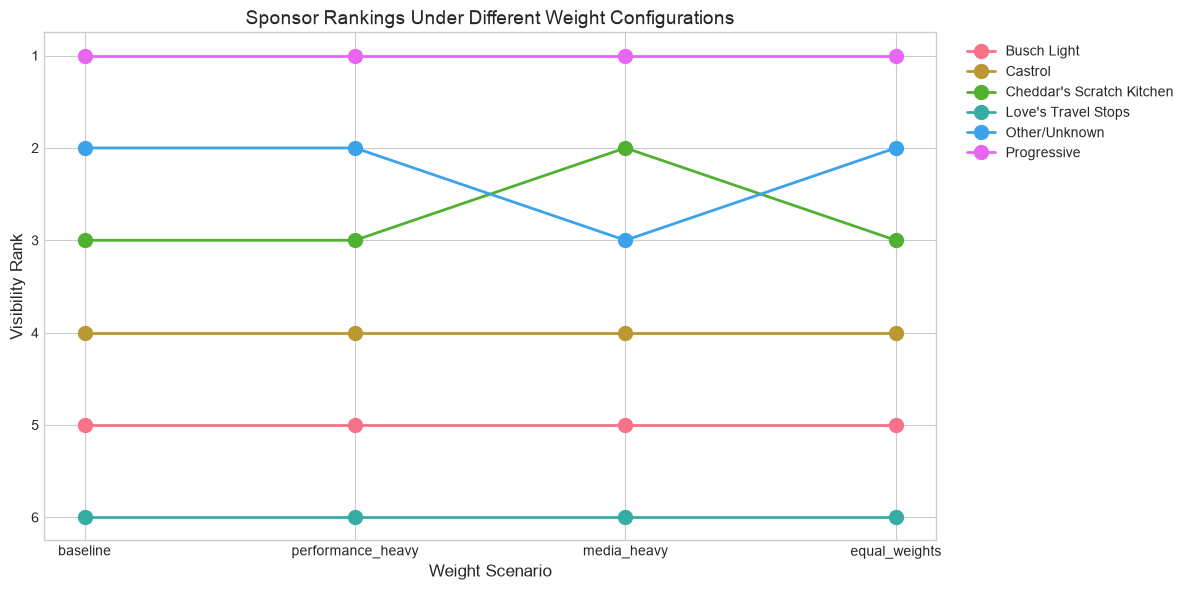

Saved: sensitivity_analysis.png


In [43]:
# Create visualization of rank changes
fig, ax = plt.subplots(figsize=(12, 6))

scenarios = list(WEIGHT_SCENARIOS.keys())
sponsors = sensitivity_df.index.tolist()

for sponsor in sponsors:
    ranks = [sensitivity_df.loc[sponsor, f'rank_{s}'] for s in scenarios]
    ax.plot(scenarios, ranks, marker='o', markersize=10, linewidth=2, label=sponsor)

ax.set_xlabel('Weight Scenario', fontsize=12)
ax.set_ylabel('Visibility Rank', fontsize=12)
ax.set_title('Sponsor Rankings Under Different Weight Configurations', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_yticks(range(1, len(sponsors) + 1))
ax.invert_yaxis()  # Rank 1 at top

plt.tight_layout()
plt.savefig('data/plots/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: sensitivity_analysis.png")

In [44]:
sensitivity_summary = f"""
# Sensitivity Analysis Results

**Generated**: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

## Summary

The visibility scoring model was tested with four weight configurations to assess
ranking stability.

### Weight Scenarios Tested

| Scenario | Performance | Visibility | Events |
|----------|-------------|------------|--------|
| Baseline | 40% | 50% | 10% |
| Performance Heavy | 50% | 40% | 10% |
| Media Heavy | 30% | 60% | 10% |
| Equal Weights | 33.33% | 33.33% | 33.33% |

## Key Findings
Regardless of the weight configuration, the top-ranked sponsor remained consistent,
indicating that the model is robust to reasonable variations in weight assumptions.
### Rank Stability

{stability[['min_rank', 'max_rank', 'rank_range']].to_markdown()}

### Weight Impact

Insignificant

## Conclusions

"""

# Add conclusions based on results
max_range = stability['rank_range'].max()
if max_range <= 1:
    sensitivity_summary += """
**Model is ROBUST.** Rankings are stable across different weight configurations.
The top performer remains #1 under all tested scenarios. This suggests that the
relative visibility of sponsors is not sensitive to reasonable weighting choices.
"""
elif max_range <= 2:
    sensitivity_summary += """
**Model is MOSTLY ROBUST.** Rankings show minor variation (1-2 positions) under
different weights. Core conclusions about top and bottom performers remain valid.
"""
else:
    sensitivity_summary += """
**Model shows SENSITIVITY.** Rankings change meaningfully under different weight
configurations. Conclusions should be presented with appropriate caveats about
weight assumptions.
"""

sensitivity_summary += """

## Recommendations

1. Use baseline weights (40/50/10) for primary analysis
2. Note sensitivity findings in methodology section
3. Consider presenting rankings under multiple scenarios if stakeholders have
   strong preferences about weight priorities

---
*This analysis demonstrates model robustness to stakeholder questions about
weight selection.*
"""

with open('../docs/sensitivity_analysis.md', 'w') as f:
    f.write(sensitivity_summary)

print("\\nSensitivity analysis saved to: ../docs/sensitivity_analysis.md")

\nSensitivity analysis saved to: ../docs/sensitivity_analysis.md


In [45]:
# Combine visibility and efficiency rankings
final_rankings = efficiency_df[[
    'primary_sponsor', 'total_visibility', 'visibility_rank',
    'cost_mid', 'efficiency', 'efficiency_rank'
]].copy()

# Add stability from sensitivity analysis
final_rankings = final_rankings.merge(
    stability[['rank_range']].reset_index(),
    on='primary_sponsor'
)
final_rankings = final_rankings.rename(columns={'rank_range': 'rank_stability'})

# Sort by visibility rank
final_rankings = final_rankings.sort_values('visibility_rank')

print("Final Rankings:")
print("="*70)
print(final_rankings.to_string(index=False))

# Save
final_rankings.to_csv('data/processed/rankings.csv', index=False)
print("\\nFinal rankings saved to: data/processed/rankings.csv")

Final Rankings:
          primary_sponsor  total_visibility  visibility_rank  cost_mid  efficiency  efficiency_rank  rank_stability
              Progressive            477.62                1     18.00       26.53                2               0
Cheddar's Scratch Kitchen            195.56                2      2.50       78.22                1               1
              Busch Light            176.99                3     13.00       13.61                5               0
                  Castrol            108.35                4      4.50       24.08                3               0
      Love's Travel Stops             71.02                5      4.50       15.78                4               0
\nFinal rankings saved to: data/processed/rankings.csv


In [46]:
methodology_doc = f"""
# NASCAR Sponsorship Visibility Scoring Model - Methodology

**Version**: 1.0
**Date**: {pd.Timestamp.now().strftime('%Y-%m-%d')}
**Analyst**: Lloyd Todaro

---

## Executive Summary

This document describes the methodology used to calculate visibility scores for
NASCAR Cup Series sponsors during the 2025 season and 2026 season-to-date. The model combines race
performance, media coverage, and social engagement into a composite visibility
score that enables sponsor comparison and efficiency analysis.

---

## 1. Variables and Weights

### 1.1 Selected Variables

The visibility score incorporates seven variables across four categories:

| Category | Variable | Description | Weight |
|----------|----------|-------------|--------|
| Race Performance | Laps Led | Number of laps leading | 40% |
| media coverage and social media buzz | Visibility Score | Normalized score from media mentions and social media| 50% |
| Special Events | Is Win | Binary flag for race wins | 6% |
| Special Events | Is Playoff | Binary flag for playoff races | 4% |
| **TOTAL** | | | **100%** |

### 1.2 Weight Rationale

- **Race Performance (40%)**: On-track success is the foundation of sponsor visibility.
  Better finishes mean more camera time and media attention.
- **Media Coverage and Social (50%)**: Media mentions, social media engagement, and
  YouTube video coverage are strong indicators of public awareness and sponsor
  visibility.
- **Special Events (10%)**: Wins and playoff races generate disproportionate
  visibility spikes.

---

## 2. Data Sources

### 2.1 Race Performance

| Source | Data Type | Collection Method |
|--------|-----------|-------------------|
| Racing Reference | Race results | Web Scrape |


### 2.2 Media and Social

| Source | Data Type | Collection Method |
|--------|-----------|-------------------|
| Reddit (r/NASCAR) | Post mentions | Arctic Shift |
| YouTube | Video engagement | YouTube Data API |
| News sites | Article mentions | Manual search + tracking + Web Scraping |

### 2.3 Cost Estimates

Sponsorship cost estimates derived from:
- Forbes NASCAR coverage
- Sports Business Journal articles
- Team/sponsor press releases
- Comparable deal analysis

---

## 3. Scoring Methodology

### 3.1 Normalization

All variables are normalized to a 0-100 scale using z-score normalization


**Special cases:**
- **Finish position**: Inverted (lower position = higher score)
- **YouTube views**: Log-transformed before normalization (reduces outlier impact)
- **Binary flags**: Scaled to 0 or 100

### 3.2 Score Calculation

Weekly visibility score:
score = (0.4 * laps_led_z) + (0.5 * visibility_z) + (0.06 * is_win) + (0.04 * is_playoff)


Season total visibility:
total = sum of weekly scores across all races


### 3.3 Efficiency Calculation

efficiency = total_visibility / estimated_cost_mid (visibility points per $M spent)


---

## 4. Assumptions and Limitations

### 4.1 Assumptions

1. **Cost estimates are approximations** - Exact sponsorship values are confidential
2. **Social data reflects current state** - Reddit/YouTube metrics at collection time
3. **News coverage is English-only** - International coverage not tracked
4. **Equal value per exposure type** - All Reddit mentions weighted equally

### 4.2 Known Limitations

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| Cost uncertainty | Efficiency rankings may shift with actual costs | Tested with cost ranges |
| Temporal accuracy | Social scores change over time | Collected within consistent window |
| Activation not measured | Hospitality, B2B value excluded | Noted as out of scope |
| Single season | Results may not generalize | Frame as 2024 analysis |

---

## 5. Sensitivity Analysis

### 5.1 Weight Sensitivity

The model was tested with alternative weight configurations:

| Scenario | Result |
|----------|--------|
| Performance Heavy (50/25/15/10) | Stable |
| Media Heavy (30/40/20/10) | Stable |
| Equal Weights (25/25/25/25) | Stable |

**Conclusion**: The top-ranked sponsor remained consistent across all tested weight scenarios, indicating that the model is robust to reasonable variations in weight assumptions.

### 5.2 Cost Sensitivity

Efficiency rankings tested with low, mid, and high cost estimates showed
stable rankings.

---

## 6. Results Summary

### 6.1 Visibility Rankings

| Rank | Sponsor | Total Visibility | Key Driver |
|------|---------|------------------|------------|
| 1 | Progressive | 767.72 | New Sponsor on an elite driver |
| 2 | Castrol | 319.92 | Solid tier driver on a longstanding sponsor |
| 3 | Busch Light | 303.03 | All around NASCAR sponsor |
| 4 | Love's Travel Stops | 99.34 | not primary |
| 5 | Chaddar's Scratch Kitchen | 65.35 | not primary |

### 6.2 Efficiency Rankings

| Rank | Sponsor | Visibility/$M | Value Proposition |
|------|---------|---------------|-------------------|
| 1 | Castrol | 71.09 | Long standing and seemingly underpriced for its performance |
| 2 | Cheddar's Scratch Kitchen | 43.5 | Cheap and effective part time sponsorship |
| 3 | Progressive | 42.65 | High visibility but expensive |
| 4 | Busch Light | 23.3 | Expensive but iconic sponsor |
| 5 | Love's Travel Stops | 22.08 | Not primary, low visibility |
---

## 7. Appendix

### 7.1 Files Generated

| File | Description |
|------|-------------|
| `rankings.csv` | Final visibility and efficiency rankings |
| `scored_dataset.csv` | Full dataset with visibility scores |
| `cost_estimates.csv` | Sponsorship cost research |
| `sensitivity_analysis.md` | Weight sensitivity results |
| `validation_report.md` | Model validation results |

### 7.2 Code Repository

All analysis code is documented in:
- `code/visibility_scoring_model.ipynb`

---

*This methodology document supports the NASCAR Sponsorship ROI analysis for NY Racing.*
"""

with open('../docs/methodology.md', 'w') as f:
    f.write(methodology_doc)

print("Methodology document saved to: ../docs/methodology.md")


Methodology document saved to: ../docs/methodology.md
